# 📈 Stock Price Prediction using LSTM and RNN

---

## Table of Contents
1. [Project Overview & Problem Statement](#1-project-overview)
2. [Setup & Import Libraries](#2-setup)
3. [Data Collection](#3-data-collection)
4. [Data Understanding & Feature Types](#4-data-understanding)
5. [Data Quality Assessment](#5-data-quality)
6. [Exploratory Data Analysis (EDA)](#6-eda)
7. [Hypothesis Formulation & Statistical Testing](#7-hypothesis)
8. [Feature Engineering](#8-feature-engineering)
9. [Data Preprocessing for Deep Learning](#9-preprocessing)
10. [Model Architecture & Theory](#10-model-theory)
11. [Model Development & Training](#11-model-development)
12. [Model Evaluation & Comparison](#12-evaluation)
13. [Prediction Analysis & Visualization](#13-prediction-analysis)
14. [Future Forecasting](#14-future-forecasting)
15. [Limitations & Challenges](#15-limitations)
16. [Conclusions & Recommendations](#16-conclusions)

---

## 1. Project Overview & Problem Statement <a name="1-project-overview"></a>

### 1.1 Business Context
Stock price prediction is a critical challenge in the financial industry. Accurate forecasting can help investors make informed decisions, optimize portfolio allocation, and manage risk effectively.

### 1.2 Problem Statement
**Objective**: Develop deep learning models (RNN and LSTM) to predict future stock closing prices based on historical price data and technical indicators.

**Key Questions:**
1. Can we predict tomorrow's closing price using historical data?
2. Do technical indicators (RSI, EMA, MACD) improve prediction accuracy?
3. Which model architecture performs best for stock prediction?
4. What are the practical limitations of ML-based stock prediction?

### 1.3 Success Metrics
- **RMSE (Root Mean Squared Error)**: Primary metric - lower is better
- **MAE (Mean Absolute Error)**: Average prediction error in dollars
- **MAPE (Mean Absolute Percentage Error)**: Percentage-based error
- **R² Score**: Variance explained by the model
- **Direction Accuracy**: Correct up/down prediction percentage

### 1.4 Project Scope
- **Stock**: Apple Inc. (AAPL) - Selected for high liquidity and data availability
- **Data Source**: NASDAQ Stock Market Dataset (Kaggle)
- **Time Period**: Full historical data available
- **Prediction Horizon**: Next-day closing price prediction

---

## 2. Setup & Import Libraries <a name="2-setup"></a>

### Required Libraries:
- **Data Manipulation**: NumPy, Pandas
- **Visualization**: Matplotlib, Seaborn
- **Deep Learning**: TensorFlow/Keras
- **Statistical Analysis**: SciPy
- **Preprocessing**: Scikit-learn

In [1]:
# ============================================================
# CORE LIBRARIES
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ============================================================
# DEEP LEARNING LIBRARIES
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ============================================================
# PREPROCESSING & METRICS
# ============================================================
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# STATISTICAL ANALYSIS
# ============================================================
from scipy import stats
from scipy.stats import shapiro, normaltest, jarque_bera

# ============================================================
# REPRODUCIBILITY
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ============================================================
# DISPLAY SETTINGS
# ============================================================
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ============================================================
# VERSION CHECK
# ============================================================
print("=" * 60)
print("ENVIRONMENT SETUP")
print("=" * 60)
print(f"Python Libraries Loaded Successfully!")
print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Random Seed: {RANDOM_SEED}")
print("=" * 60)

ENVIRONMENT SETUP
Python Libraries Loaded Successfully!
TensorFlow Version: 2.20.0
NumPy Version: 2.3.5
Pandas Version: 2.3.1
Random Seed: 42


## 3. Data Collection <a name="3-data-collection"></a>

### 3.1 Data Source
- **Dataset**: NASDAQ Stock Market Dataset
- **Source**: Kaggle (jacksoncrow/stock-market-dataset)
- **Format**: CSV files organized by stock symbol
- **Coverage**: Historical daily prices for all NASDAQ-traded stocks

In [2]:
# ============================================================
# 3.2 DOWNLOAD DATASET FROM KAGGLE
# ============================================================
import kagglehub

print("Downloading NASDAQ Stock Market Dataset...")
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")
print(f"✅ Dataset downloaded successfully!")
print(f"📁 Path: {path}")

# ============================================================
# 3.3 EXPLORE DATASET STRUCTURE
# ============================================================
print("\n" + "=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        file_count = len(os.listdir(item_path))
        print(f"📁 {item}/ - {file_count:,} files")
    else:
        file_size = os.path.getsize(item_path) / 1024  # KB
        print(f"📄 {item} - {file_size:.2f} KB")

✅ Dataset downloaded successfully!
📁 Path: /Users/nusratbegum/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2

DATASET STRUCTURE
📄 symbols_valid_meta.csv - 597.29 KB
📁 stocks/ - 5,884 files
📁 etfs/ - 2,165 files


In [3]:
# ============================================================
# 3.4 LOAD METADATA
# ============================================================
meta_df = pd.read_csv(os.path.join(path, 'symbols_valid_meta.csv'))

print("=" * 60)
print("METADATA OVERVIEW")
print("=" * 60)
print(f"Total Symbols: {len(meta_df):,}")
print(f"Columns: {meta_df.columns.tolist()}")

# Display sample metadata
print("\n📊 Sample Metadata (Top 10 Stocks):")
display(meta_df.head(10))

METADATA OVERVIEW
Total Symbols: 8,049
Columns: ['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange', 'Market Category', 'ETF', 'Round Lot Size', 'Test Issue', 'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares']

📊 Sample Metadata (Top 10 Stocks):


,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0000,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0000,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0000,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0000,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0000,N,NaN,AADR,AADR,N
5,Y,AAL,"American Airlines Group, Inc. - Common Stock",Q,Q,N,100.0000,N,N,NaN,AAL,N
6,Y,AAMC,Altisource Asset Management Corp Com,A,,N,100.0000,N,NaN,AAMC,AAMC,N
7,Y,AAME,Atlantic American Corporation - Common Stock,Q,G,N,100.0000,N,N,NaN,AAME,N
8,Y,AAN,"Aaron's, Inc. Common Stock",N,,N,100.0000,N,NaN,AAN,AAN,N
9,Y,AAOI,"Applied Optoelectronics, Inc. - Common Stock",Q,G,N,100.0000,N,N,NaN,AAOI,N


In [4]:
# ============================================================
# 3.5 LOAD TARGET STOCK DATA (APPLE - AAPL)
# ============================================================
STOCK_SYMBOL = 'AAPL'
stock_path = os.path.join(path, 'stocks', f'{STOCK_SYMBOL}.csv')

# Load and preprocess
df = pd.read_csv(stock_path)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print("=" * 60)
print(f"STOCK DATA LOADED: {STOCK_SYMBOL}")
print("=" * 60)
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
print(f"⏱️ Time Span: {(df.index.max() - df.index.min()).days:,} days")
print(f"📈 Trading Days: {len(df):,}")

# Display raw data
print("\n📋 Raw Data Sample:")
display(df.head())

STOCK DATA LOADED: AAPL
📊 Shape: 9,909 rows × 6 columns
📅 Date Range: 1980-12-12 to 2020-04-01
⏱️ Time Span: 14,355 days
📈 Trading Days: 9,909

📋 Raw Data Sample:


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.5134,0.5156,0.5134,0.5134,0.4068,117258400
1980-12-15,0.4888,0.4888,0.4866,0.4866,0.3856,43971200
1980-12-16,0.4531,0.4531,0.4509,0.4509,0.3573,26432000
1980-12-17,0.4621,0.4643,0.4621,0.4621,0.3661,21610400
1980-12-18,0.4754,0.4777,0.4754,0.4754,0.3767,18362400


## 4. Data Understanding & Feature Types <a name="4-data-understanding"></a>

### 4.1 Data Dictionary
Understanding each feature in our dataset is crucial for proper analysis and modeling.

In [5]:
# ============================================================
# 4.2 DATA DICTIONARY
# ============================================================
data_dictionary = pd.DataFrame({
    'Feature': ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'],
    'Description': [
        'Trading date',
        'Opening price at market open',
        'Highest price during the trading day',
        'Lowest price during the trading day',
        'Closing price at market close (adjusted for splits)',
        'Closing price adjusted for both dividends and splits',
        'Number of shares traded during the day'
    ],
    'Data Type': ['DateTime (Index)', 'Float64', 'Float64', 'Float64', 'Float64', 'Float64', 'Int64'],
    'Feature Type': ['Temporal', 'Continuous', 'Continuous', 'Continuous', 'Continuous', 'Continuous', 'Continuous'],
    'Role': ['Index', 'Input Feature', 'Input Feature', 'Input Feature', 'Target Variable', 'Input Feature', 'Input Feature'],
    'Unit': ['Date', 'USD ($)', 'USD ($)', 'USD ($)', 'USD ($)', 'USD ($)', 'Shares']
})

print("=" * 80)
print("DATA DICTIONARY")
print("=" * 80)
display(data_dictionary)

DATA DICTIONARY


,Feature,Description,Data Type,Feature Type,Role,Unit
0,Date,Trading date,DateTime (Index),Temporal,Index,Date
1,Open,Opening price at market open,Float64,Continuous,Input Feature,USD ($)
2,High,Highest price during the trading day,Float64,Continuous,Input Feature,USD ($)
3,Low,Lowest price during the trading day,Float64,Continuous,Input Feature,USD ($)
4,Close,Closing price at market close (adjusted for sp...,Float64,Continuous,Target Variable,USD ($)
5,Adj Close,Closing price adjusted for both dividends and ...,Float64,Continuous,Input Feature,USD ($)
6,Volume,Number of shares traded during the day,Int64,Continuous,Input Feature,Shares


In [6]:
# ============================================================
# 4.3 FEATURE TYPE ANALYSIS
# ============================================================
print("=" * 80)
print("FEATURE TYPE ANALYSIS")
print("=" * 80)

# Analyze each column
feature_analysis = []
for col in df.columns:
    feature_analysis.append({
        'Feature': col,
        'Data Type': str(df[col].dtype),
        'Non-Null Count': df[col].notna().sum(),
        'Null Count': df[col].isna().sum(),
        'Unique Values': df[col].nunique(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Mean': df[col].mean(),
        'Std': df[col].std()
    })

feature_df = pd.DataFrame(feature_analysis)
display(feature_df)

# ============================================================
# 4.4 FEATURE CLASSIFICATION
# ============================================================
print("\n" + "=" * 80)
print("FEATURE CLASSIFICATION")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────┐
│                    FEATURE TYPES SUMMARY                        │
├─────────────────────────────────────────────────────────────────┤
│  📊 CONTINUOUS NUMERICAL FEATURES (6):                          │
│     • Open, High, Low, Close, Adj Close (Price in USD)          │
│     • Volume (Number of shares)                                 │
│                                                                 │
│  📅 TEMPORAL FEATURES (1):                                      │
│     • Date (Index) - Used for time series ordering              │
│                                                                 │
│  🎯 TARGET VARIABLE:                                            │
│     • Close - Next day's closing price prediction               │
│                                                                 │
│  📈 DERIVED FEATURES (To be created):                           │
│     • Technical Indicators (RSI, EMA, MACD)                     │
│     • Price Changes & Returns                                   │
│     • Volatility Measures                                       │
└─────────────────────────────────────────────────────────────────┘
""")

FEATURE TYPE ANALYSIS


,Feature,Data Type,Non-Null Count,Null Count,Unique Values,Min,Max,Mean,Std
0,Open,float64,9909,0,5280,0.1987,324.7400,32.6068,58.4158
1,High,float64,9909,0,5220,0.1987,327.8500,32.9361,59.0016
2,Low,float64,9909,0,5197,0.1964,323.3500,32.2776,57.8830
3,Close,float64,9909,0,5387,0.1964,327.2000,32.6180,58.4719
4,Adj Close,float64,9909,0,6915,0.1556,327.2000,30.5766,56.7463
5,Volume,int64,9909,0,9350,347200.0000,1855410200.0000,85829159.2996,85971948.7614



FEATURE CLASSIFICATION

┌─────────────────────────────────────────────────────────────────┐
│                    FEATURE TYPES SUMMARY                        │
├─────────────────────────────────────────────────────────────────┤
│  📊 CONTINUOUS NUMERICAL FEATURES (6):                          │
│     • Open, High, Low, Close, Adj Close (Price in USD)          │
│     • Volume (Number of shares)                                 │
│                                                                 │
│  📅 TEMPORAL FEATURES (1):                                      │
│     • Date (Index) - Used for time series ordering              │
│                                                                 │
│  🎯 TARGET VARIABLE:                                            │
│     • Close - Next day's closing price prediction               │
│                                                                 │
│  📈 DERIVED FEATURES (To be created):                           │
│     • Technical Indicator

## 5. Data Quality Assessment <a name="5-data-quality"></a>

A thorough data quality check ensures reliable analysis and modeling.

5.1 MISSING VALUES ANALYSIS


,Feature,Missing Count,Missing %,Status
0,Open,0,0.0000,✅ Complete
1,High,0,0.0000,✅ Complete
2,Low,0,0.0000,✅ Complete
3,Close,0,0.0000,✅ Complete
4,Adj Close,0,0.0000,✅ Complete
5,Volume,0,0.0000,✅ Complete


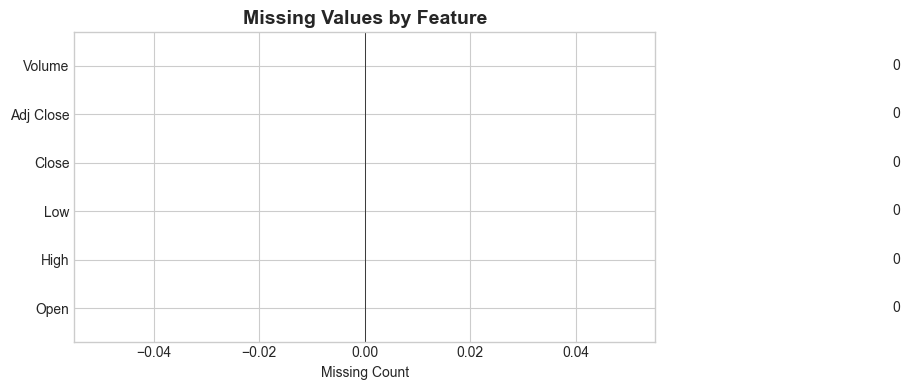


✅ Total Missing Values: 0


In [7]:
# ============================================================
# 5.1 MISSING VALUES ANALYSIS
# ============================================================
print("=" * 80)
print("5.1 MISSING VALUES ANALYSIS")
print("=" * 80)

missing_data = pd.DataFrame({
    'Feature': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100)
})
missing_data['Status'] = missing_data['Missing Count'].apply(lambda x: '✅ Complete' if x == 0 else '⚠️ Has Missing')

display(missing_data)

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if x == 0 else 'red' for x in missing_data['Missing Count']]
bars = ax.barh(missing_data['Feature'], missing_data['Missing Count'], color=colors, alpha=0.7)
ax.set_xlabel('Missing Count')
ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
for bar, val in zip(bars, missing_data['Missing Count']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            f'{val}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n✅ Total Missing Values: {df.isnull().sum().sum()}")

In [8]:
# ============================================================
# 5.2 DUPLICATE RECORDS CHECK
# ============================================================
print("=" * 80)
print("5.2 DUPLICATE RECORDS CHECK")
print("=" * 80)

# Check for duplicate dates
duplicate_dates = df.index.duplicated().sum()
print(f"Duplicate Dates: {duplicate_dates}")

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_rows}")

if duplicate_dates == 0 and duplicate_rows == 0:
    print("✅ No duplicates found - Data integrity maintained")
else:
    print("⚠️ Duplicates detected - Requires cleaning")

5.2 DUPLICATE RECORDS CHECK
Duplicate Dates: 0
Duplicate Rows: 0
✅ No duplicates found - Data integrity maintained


In [9]:
# ============================================================
# 5.3 OUTLIER DETECTION (IQR Method)
# ============================================================
print("=" * 80)
print("5.3 OUTLIER DETECTION (IQR Method)")
print("=" * 80)

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outlier_summary = []
for col in df.columns:
    count, lower, upper = detect_outliers_iqr(df, col)
    outlier_summary.append({
        'Feature': col,
        'Outlier Count': count,
        'Outlier %': round(count / len(df) * 100, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

print("\n📊 Note: Outliers in stock data often represent legitimate price movements")
print("   (e.g., earnings announcements, market crashes) and should be retained.")

5.3 OUTLIER DETECTION (IQR Method)


,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,Open,1543,15.5700,-51.0200,87.8900
1,High,1537,15.5100,-51.6800,89.0300
2,Low,1540,15.5400,-50.3700,86.7500
3,Close,1539,15.5300,-50.9600,87.8000
4,Adj Close,1558,15.7200,-44.2700,76.2300
5,Volume,705,7.1100,-77893050.0000,217934550.0000



📊 Note: Outliers in stock data often represent legitimate price movements
   (e.g., earnings announcements, market crashes) and should be retained.


In [10]:
# ============================================================
# 5.4 DATA CONSISTENCY CHECK
# ============================================================
print("=" * 80)
print("5.4 DATA CONSISTENCY CHECK")
print("=" * 80)

# Check logical consistency: High >= Low, High >= Open/Close, Low <= Open/Close
inconsistencies = []

# High should be >= Low
high_low_issue = (df['High'] < df['Low']).sum()
inconsistencies.append(('High < Low', high_low_issue))

# High should be >= Open and Close
high_open_issue = (df['High'] < df['Open']).sum()
high_close_issue = (df['High'] < df['Close']).sum()
inconsistencies.append(('High < Open', high_open_issue))
inconsistencies.append(('High < Close', high_close_issue))

# Low should be <= Open and Close
low_open_issue = (df['Low'] > df['Open']).sum()
low_close_issue = (df['Low'] > df['Close']).sum()
inconsistencies.append(('Low > Open', low_open_issue))
inconsistencies.append(('Low > Close', low_close_issue))

# Volume should be non-negative
negative_volume = (df['Volume'] < 0).sum()
inconsistencies.append(('Negative Volume', negative_volume))

consistency_df = pd.DataFrame(inconsistencies, columns=['Check', 'Issues Found'])
consistency_df['Status'] = consistency_df['Issues Found'].apply(lambda x: '✅ Pass' if x == 0 else '⚠️ Fail')
display(consistency_df)

if consistency_df['Issues Found'].sum() == 0:
    print("\n✅ All consistency checks passed - Data is logically consistent")

5.4 DATA CONSISTENCY CHECK


,Check,Issues Found,Status
0,High < Low,0,✅ Pass
1,High < Open,0,✅ Pass
2,High < Close,0,✅ Pass
3,Low > Open,0,✅ Pass
4,Low > Close,0,✅ Pass
5,Negative Volume,0,✅ Pass



✅ All consistency checks passed - Data is logically consistent


In [11]:
# ============================================================
# 5.5 DATA QUALITY SUMMARY
# ============================================================
print("=" * 80)
print("DATA QUALITY SUMMARY")
print("=" * 80)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    DATA QUALITY REPORT                          │
├─────────────────────────────────────────────────────────────────┤
│  📊 Total Records: {len(df):,}                                   
│  📅 Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}
│                                                                 │
│  ✅ Missing Values: {df.isnull().sum().sum()}                                         
│  ✅ Duplicate Records: {duplicate_rows}                                     
│  ✅ Data Consistency: All checks passed                         
│                                                                 │
│  📈 Data Quality Score: EXCELLENT                               │
│  🚀 Ready for Analysis: YES                                     │
└─────────────────────────────────────────────────────────────────┘
""")

DATA QUALITY SUMMARY

┌─────────────────────────────────────────────────────────────────┐
│                    DATA QUALITY REPORT                          │
├─────────────────────────────────────────────────────────────────┤
│  📊 Total Records: 9,909                                   
│  📅 Date Range: 1980-12-12 to 2020-04-01
│                                                                 │
│  ✅ Missing Values: 0                                         
│  ✅ Duplicate Records: 0                                     
│  ✅ Data Consistency: All checks passed                         
│                                                                 │
│  📈 Data Quality Score: EXCELLENT                               │
│  🚀 Ready for Analysis: YES                                     │
└─────────────────────────────────────────────────────────────────┘



## 6. Exploratory Data Analysis (EDA) <a name="6-eda"></a>

### 6.1 Descriptive Statistics
Let's perform comprehensive statistical analysis of our data.

In [12]:
# ============================================================
# 6.1 DESCRIPTIVE STATISTICS
# ============================================================
print("=" * 80)
print("6.1 DESCRIPTIVE STATISTICS")
print("=" * 80)

# Comprehensive statistics
stats_df = df.describe().T
stats_df['median'] = df.median()
stats_df['skewness'] = df.skew()
stats_df['kurtosis'] = df.kurtosis()
stats_df['range'] = stats_df['max'] - stats_df['min']
stats_df['cv'] = (stats_df['std'] / stats_df['mean']) * 100  # Coefficient of Variation

display(stats_df.round(4))

print("\n📊 Key Insights:")
print(f"   • Close Price Range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")
print(f"   • Average Close Price: ${df['Close'].mean():.2f}")
print(f"   • Average Daily Volume: {df['Volume'].mean():,.0f} shares")
print(f"   • Close Price Volatility (CV): {(df['Close'].std()/df['Close'].mean()*100):.2f}%")

6.1 DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis,range,cv
Open,9909.0000,32.6068,58.4158,0.1987,1.0714,1.7293,35.8000,324.7400,1.7293,2.1721,4.4574,324.5413,179.1518
High,9909.0000,32.9361,59.0016,0.1987,1.0893,1.7589,36.2657,327.8500,1.7589,2.1788,4.5050,327.6513,179.1396
Low,9909.0000,32.2776,57.8830,0.1964,1.0486,1.6964,35.3286,323.3500,1.6964,2.1715,4.4490,323.1536,179.3290
Close,9909.0000,32.6180,58.4719,0.1964,1.0714,1.7321,35.7614,327.2000,1.7321,2.1769,4.4912,327.0036,179.2625
Adj Close,9909.0000,30.5766,56.7463,0.1556,0.9176,1.4662,31.0424,327.2000,1.4662,2.3228,5.3121,327.0444,185.5874
Volume,9909.0000,85829159.2996,85971948.7614,347200.0000,33042300.0000,57664900.0000,106999200.0000,1855410200.0000,57664900.0000,3.4876,29.3794,1855063000.0000,100.1664



📊 Key Insights:
   • Close Price Range: $0.20 - $327.20
   • Average Close Price: $32.62
   • Average Daily Volume: 85,829,159 shares
   • Close Price Volatility (CV): 179.26%


6.2 UNIVARIATE ANALYSIS - DISTRIBUTION PLOTS


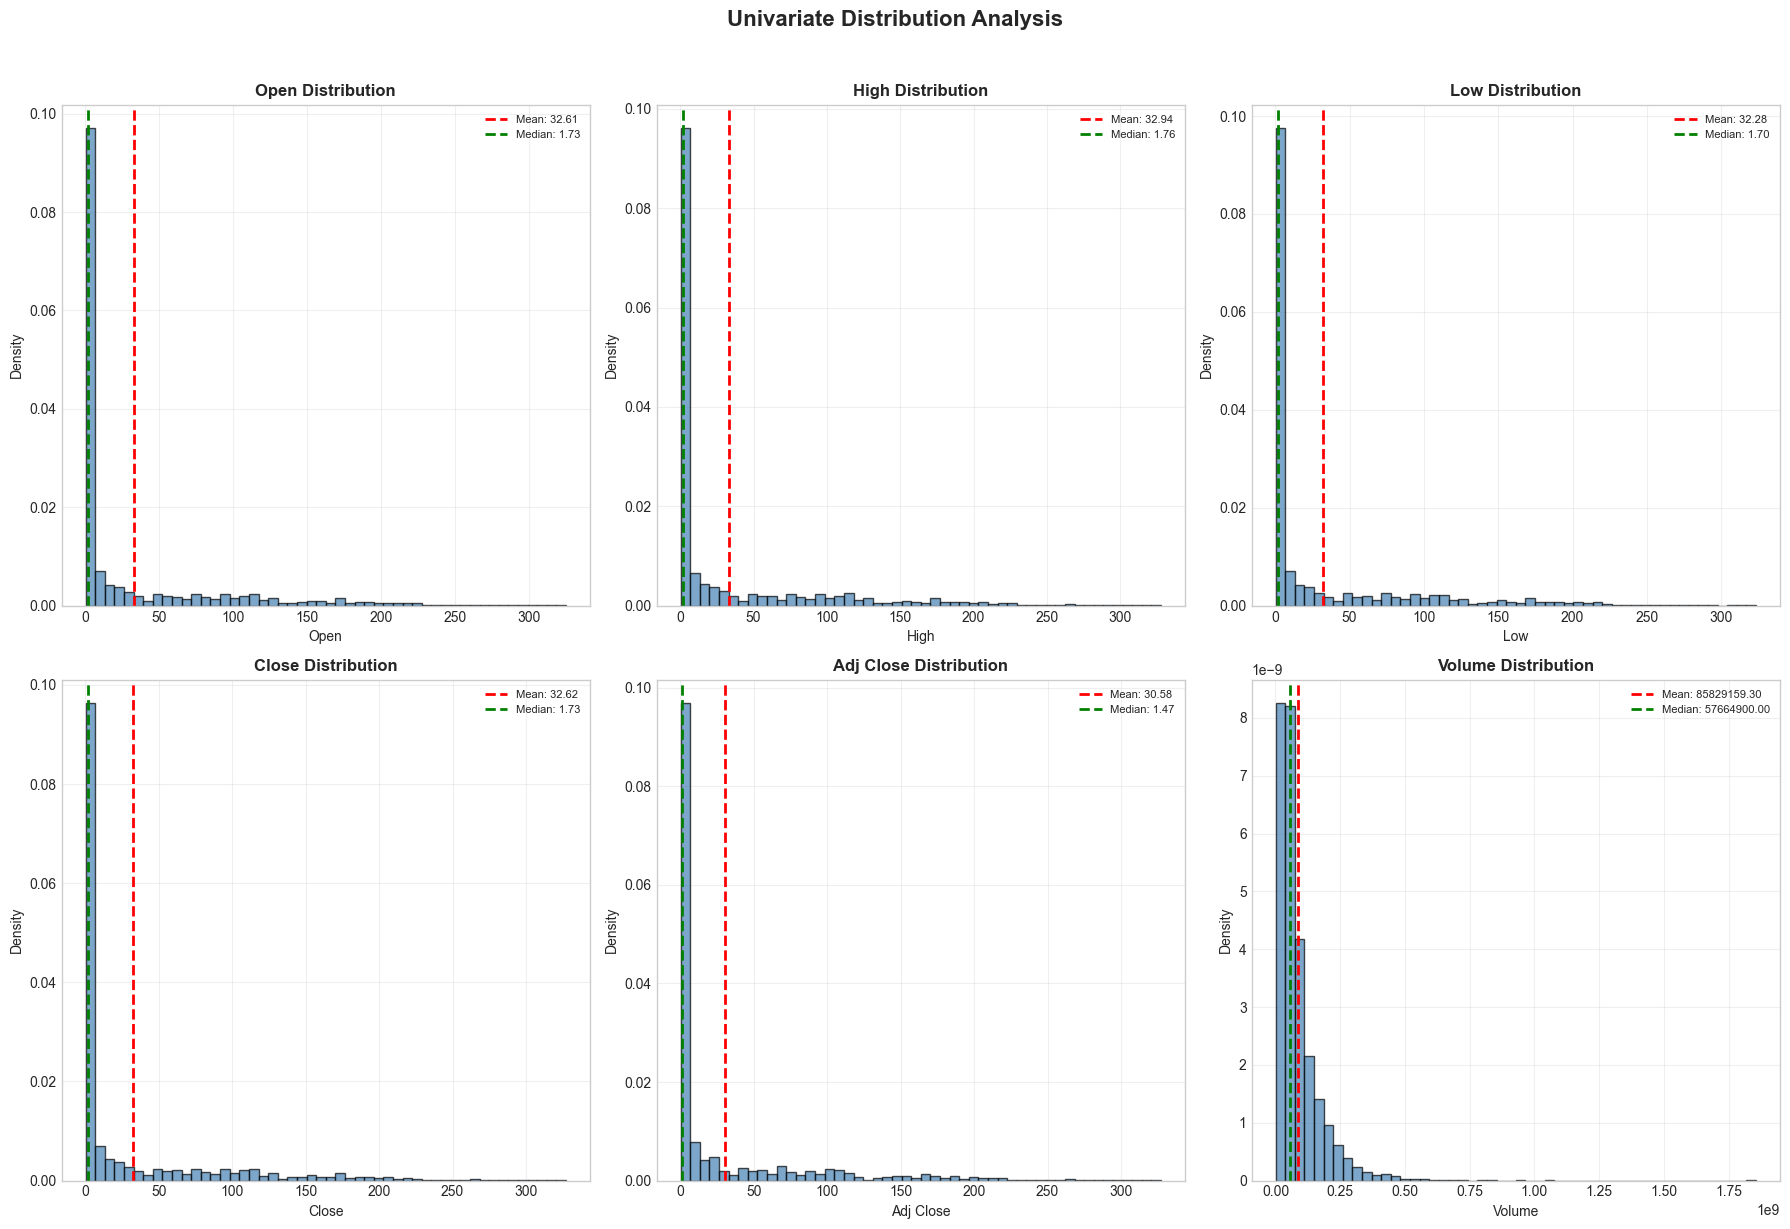

In [13]:
# ============================================================
# 6.2 UNIVARIATE ANALYSIS - DISTRIBUTION PLOTS
# ============================================================
print("=" * 80)
print("6.2 UNIVARIATE ANALYSIS - DISTRIBUTION PLOTS")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    ax = axes[idx]
    
    # Histogram with KDE
    ax.hist(df[col], bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Add mean and median lines
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.2f}')
    
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Univariate Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

6.3 TIME SERIES VISUALIZATION


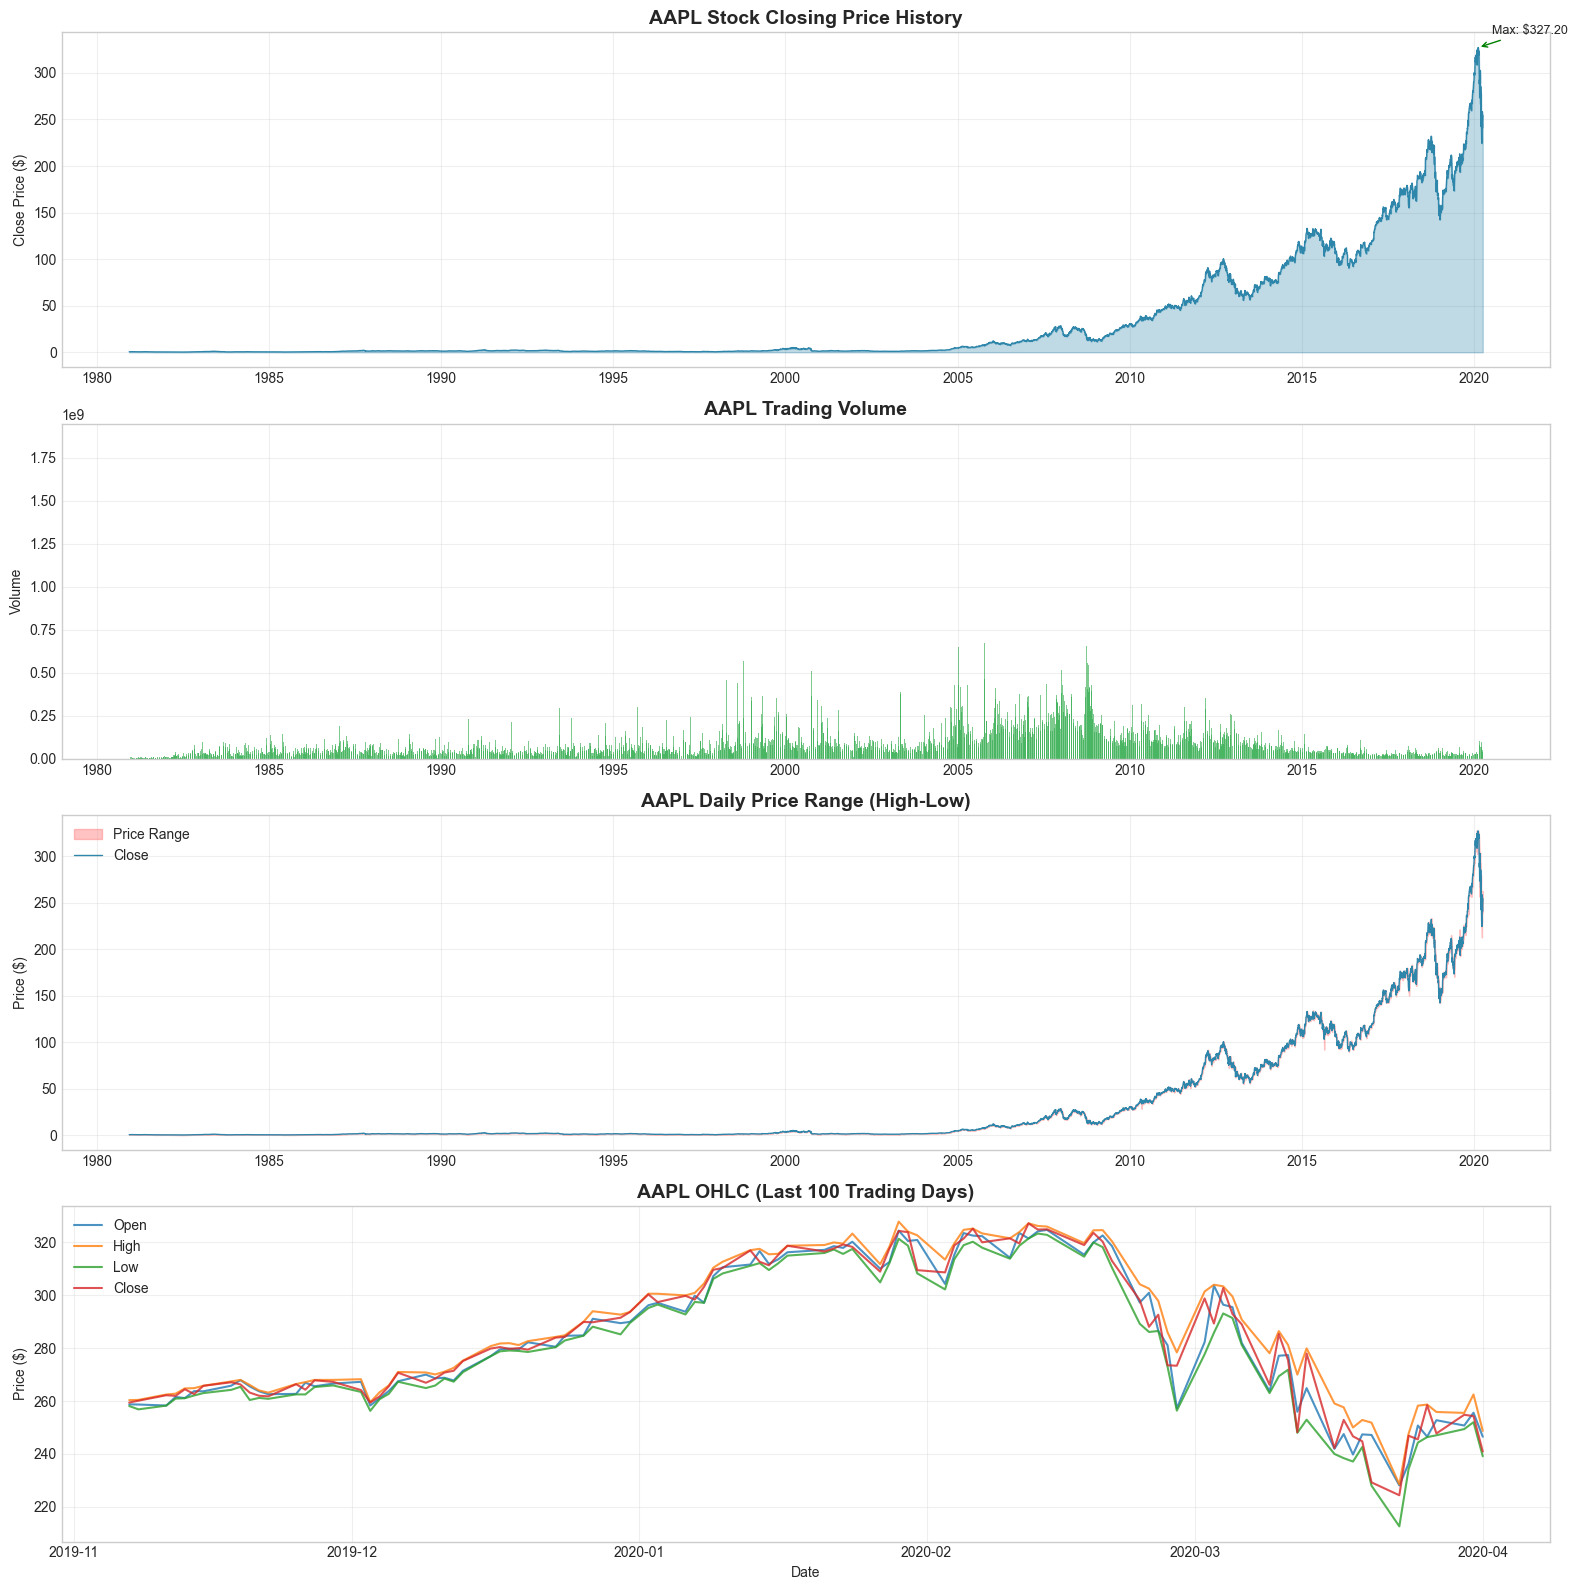

In [14]:
# ============================================================
# 6.3 TIME SERIES VISUALIZATION
# ============================================================
print("=" * 80)
print("6.3 TIME SERIES VISUALIZATION")
print("=" * 80)

fig, axes = plt.subplots(4, 1, figsize=(16, 16))

# 1. Closing Price Over Time
axes[0].plot(df.index, df['Close'], color='#2E86AB', linewidth=1)
axes[0].fill_between(df.index, df['Close'], alpha=0.3, color='#2E86AB')
axes[0].set_title(f'{STOCK_SYMBOL} Stock Closing Price History', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Close Price ($)')
axes[0].grid(True, alpha=0.3)

# Add annotations for significant events
max_price_date = df['Close'].idxmax()
min_price_date = df['Close'].idxmin()
axes[0].annotate(f'Max: ${df["Close"].max():.2f}', xy=(max_price_date, df['Close'].max()),
                 xytext=(10, 10), textcoords='offset points', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='green'))

# 2. Volume Over Time
axes[1].bar(df.index, df['Volume'], color='#28A745', alpha=0.6, width=2)
axes[1].set_title(f'{STOCK_SYMBOL} Trading Volume', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

# 3. Price Range (High-Low) Over Time
axes[2].fill_between(df.index, df['Low'], df['High'], alpha=0.4, color='#FF6B6B', label='Price Range')
axes[2].plot(df.index, df['Close'], color='#2E86AB', linewidth=1, label='Close')
axes[2].set_title(f'{STOCK_SYMBOL} Daily Price Range (High-Low)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Price ($)')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

# 4. OHLC for Recent Data (Last 100 days)
recent = df.tail(100)
axes[3].plot(recent.index, recent['Open'], label='Open', alpha=0.8, linewidth=1.5)
axes[3].plot(recent.index, recent['High'], label='High', alpha=0.8, linewidth=1.5)
axes[3].plot(recent.index, recent['Low'], label='Low', alpha=0.8, linewidth=1.5)
axes[3].plot(recent.index, recent['Close'], label='Close', alpha=0.8, linewidth=1.5)
axes[3].set_title(f'{STOCK_SYMBOL} OHLC (Last 100 Trading Days)', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Price ($)')
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper left')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

6.4 BIVARIATE ANALYSIS - CORRELATION MATRIX


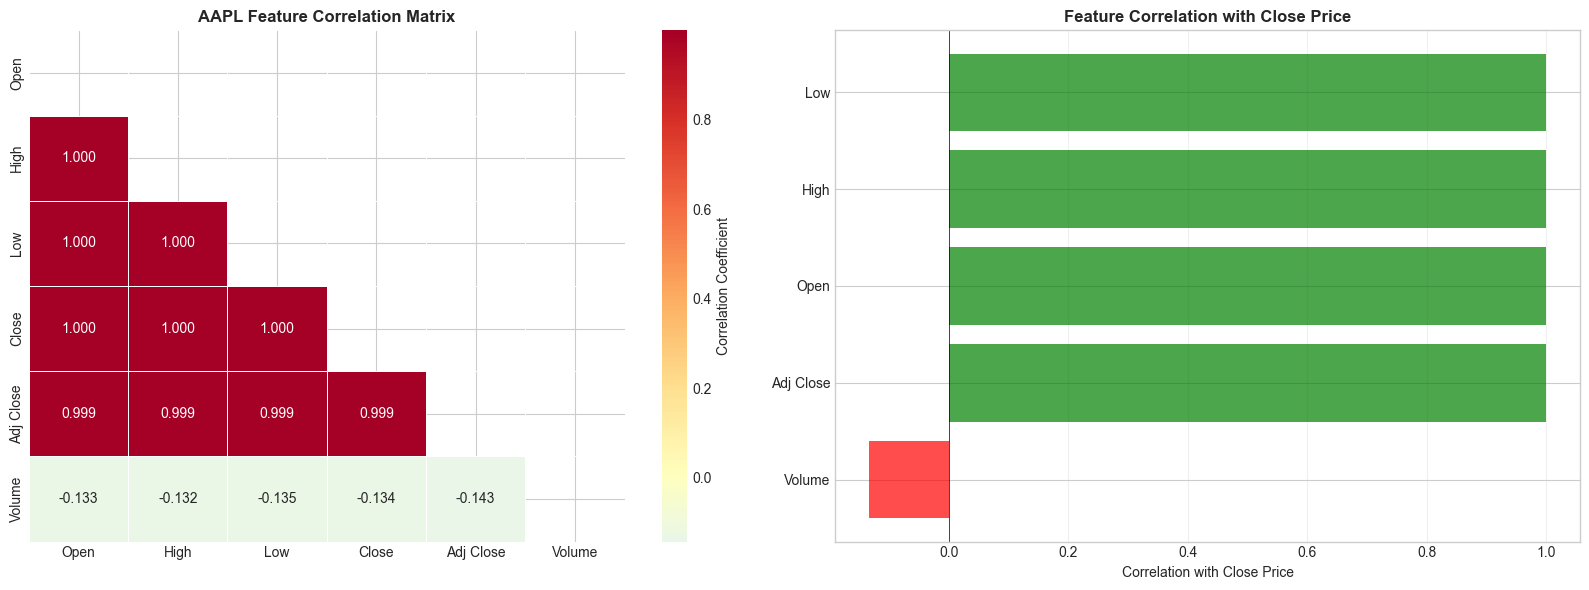


📊 Correlation Insights:
   • Open, High, Low, Adj Close are highly correlated with Close (>0.99)
   • Volume shows weak correlation with price features
   • High multicollinearity exists among price features (expected for OHLC data)


In [15]:
# ============================================================
# 6.4 BIVARIATE ANALYSIS - CORRELATION ANALYSIS
# ============================================================
print("=" * 80)
print("6.4 BIVARIATE ANALYSIS - CORRELATION MATRIX")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation Matrix Heatmap
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.3f', linewidths=0.5, ax=axes[0], mask=mask,
            cbar_kws={'label': 'Correlation Coefficient'})
axes[0].set_title(f'{STOCK_SYMBOL} Feature Correlation Matrix', fontsize=12, fontweight='bold')

# Correlation Bar Plot (with Close)
close_corr = correlation_matrix['Close'].drop('Close').sort_values(ascending=True)
colors = ['green' if x > 0 else 'red' for x in close_corr]
axes[1].barh(close_corr.index, close_corr.values, color=colors, alpha=0.7)
axes[1].set_xlabel('Correlation with Close Price')
axes[1].set_title('Feature Correlation with Close Price', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Correlation Insights:")
print("   • Open, High, Low, Adj Close are highly correlated with Close (>0.99)")
print("   • Volume shows weak correlation with price features")
print("   • High multicollinearity exists among price features (expected for OHLC data)")

6.5 TEMPORAL PATTERNS ANALYSIS


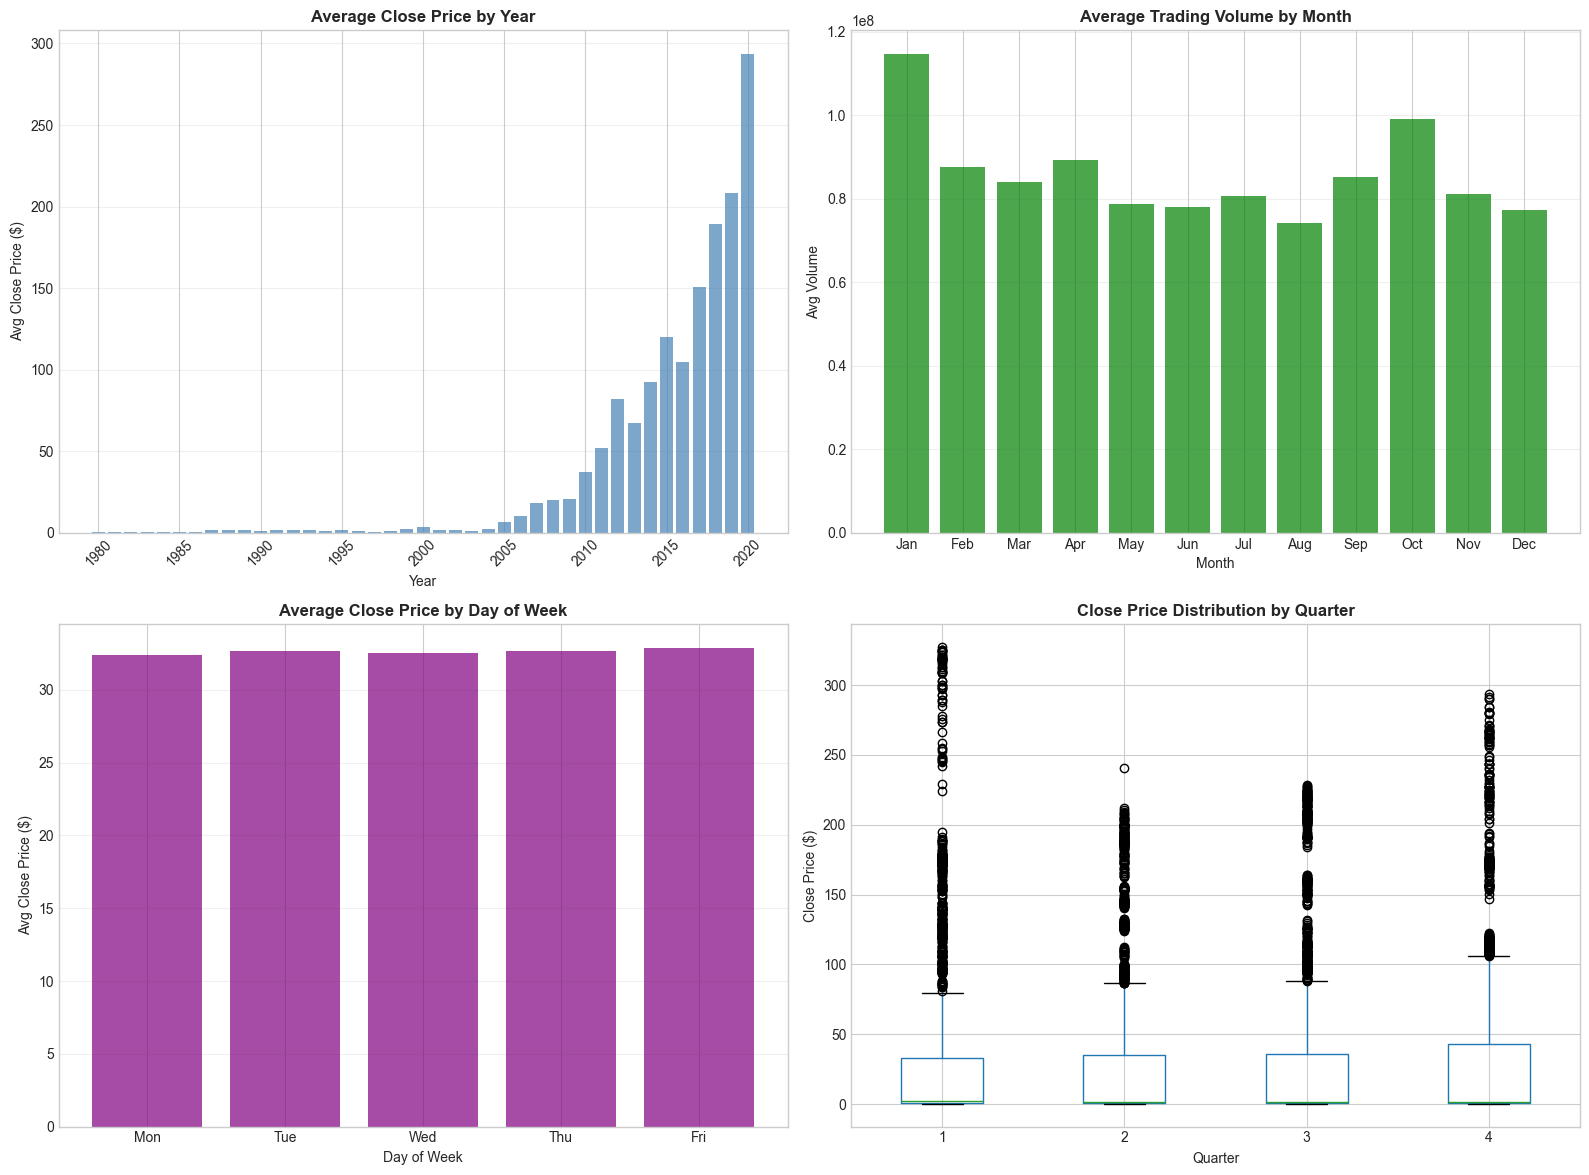

In [16]:
# ============================================================
# 6.5 TEMPORAL PATTERNS ANALYSIS
# ============================================================
print("=" * 80)
print("6.5 TEMPORAL PATTERNS ANALYSIS")
print("=" * 80)

# Add temporal features for analysis
df_temporal = df.copy()
df_temporal['Year'] = df_temporal.index.year
df_temporal['Month'] = df_temporal.index.month
df_temporal['DayOfWeek'] = df_temporal.index.dayofweek
df_temporal['Quarter'] = df_temporal.index.quarter

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average Close Price by Year
yearly_avg = df_temporal.groupby('Year')['Close'].mean()
axes[0, 0].bar(yearly_avg.index, yearly_avg.values, color='steelblue', alpha=0.7)
axes[0, 0].set_title('Average Close Price by Year', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Avg Close Price ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Average Volume by Month
monthly_vol = df_temporal.groupby('Month')['Volume'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 1].bar(range(1, 13), monthly_vol.values, color='green', alpha=0.7)
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_names)
axes[0, 1].set_title('Average Trading Volume by Month', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Avg Volume')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Average Close by Day of Week
dow_avg = df_temporal.groupby('DayOfWeek')['Close'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
axes[1, 0].bar(range(5), dow_avg.values[:5], color='purple', alpha=0.7)
axes[1, 0].set_xticks(range(5))
axes[1, 0].set_xticklabels(day_names)
axes[1, 0].set_title('Average Close Price by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Avg Close Price ($)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Box plot by Quarter
df_temporal.boxplot(column='Close', by='Quarter', ax=axes[1, 1])
axes[1, 1].set_title('Close Price Distribution by Quarter', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Quarter')
axes[1, 1].set_ylabel('Close Price ($)')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

6.6 DAILY RETURNS ANALYSIS


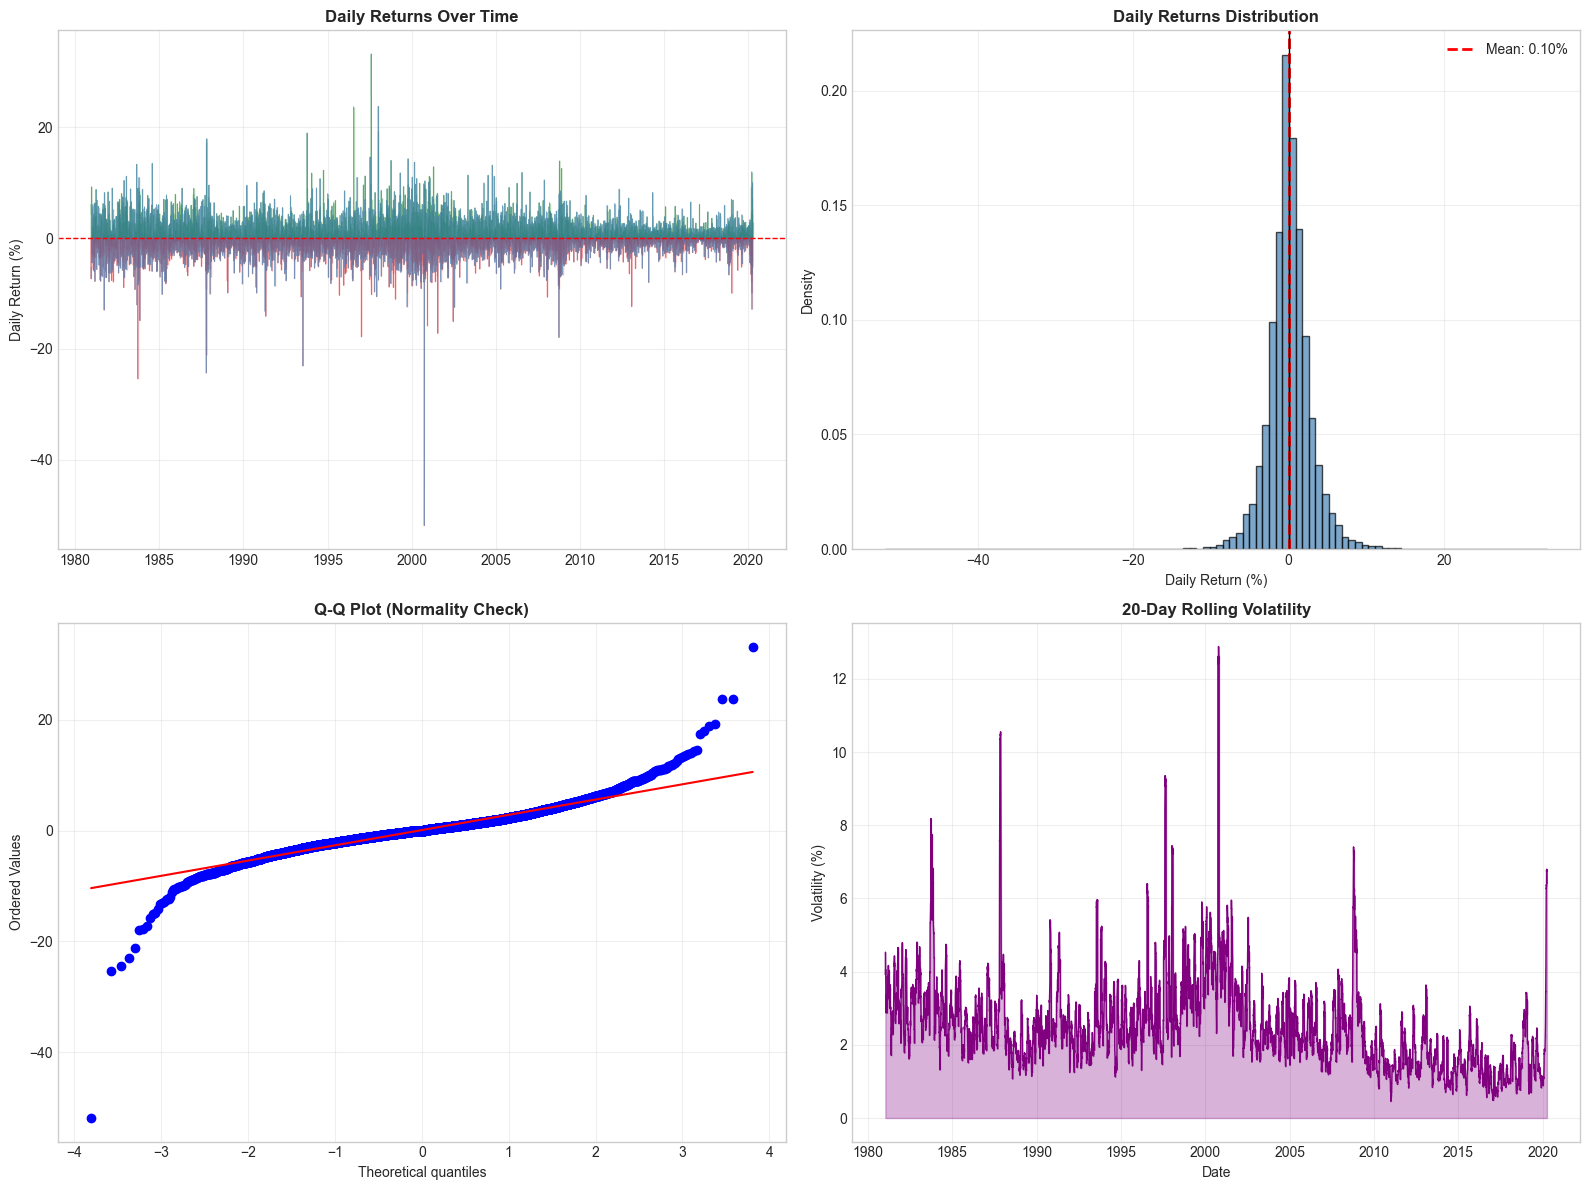


📊 Daily Returns Statistics:
   • Mean Daily Return: 0.1041%
   • Std Dev (Daily Volatility): 2.8738%
   • Max Daily Gain: 33.23%
   • Max Daily Loss: -51.87%
   • Skewness: -0.3837
   • Kurtosis: 18.0090


In [17]:
# ============================================================
# 6.6 DAILY RETURNS ANALYSIS
# ============================================================
print("=" * 80)
print("6.6 DAILY RETURNS ANALYSIS")
print("=" * 80)

# Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Daily Returns Time Series
axes[0, 0].plot(df.index, df['Daily_Return'], color='steelblue', alpha=0.7, linewidth=0.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].fill_between(df.index, df['Daily_Return'], 0, 
                         where=df['Daily_Return'] > 0, color='green', alpha=0.3)
axes[0, 0].fill_between(df.index, df['Daily_Return'], 0, 
                         where=df['Daily_Return'] < 0, color='red', alpha=0.3)
axes[0, 0].set_title('Daily Returns Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Daily Return (%)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Daily Returns Distribution
axes[0, 1].hist(df['Daily_Return'].dropna(), bins=100, density=True, alpha=0.7, 
                color='steelblue', edgecolor='black')
axes[0, 1].axvline(df['Daily_Return'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["Daily_Return"].mean():.2f}%')
axes[0, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[0, 1].set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Daily Return (%)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. QQ Plot for Normality Check
stats.probplot(df['Daily_Return'].dropna(), dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Rolling Volatility (20-day)
df['Rolling_Volatility'] = df['Daily_Return'].rolling(window=20).std()
axes[1, 1].plot(df.index, df['Rolling_Volatility'], color='purple', linewidth=1)
axes[1, 1].fill_between(df.index, df['Rolling_Volatility'], alpha=0.3, color='purple')
axes[1, 1].set_title('20-Day Rolling Volatility', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Volatility (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print(f"\n📊 Daily Returns Statistics:")
print(f"   • Mean Daily Return: {df['Daily_Return'].mean():.4f}%")
print(f"   • Std Dev (Daily Volatility): {df['Daily_Return'].std():.4f}%")
print(f"   • Max Daily Gain: {df['Daily_Return'].max():.2f}%")
print(f"   • Max Daily Loss: {df['Daily_Return'].min():.2f}%")
print(f"   • Skewness: {df['Daily_Return'].skew():.4f}")
print(f"   • Kurtosis: {df['Daily_Return'].kurtosis():.4f}")

## 7. Hypothesis Formulation & Statistical Testing <a name="7-hypothesis"></a>

Before building predictive models, let's formulate and test hypotheses about our data.

### Hypotheses to Test:
1. **H1**: Daily returns follow a normal distribution
2. **H2**: There is significant autocorrelation in stock prices (prices depend on previous values)
3. **H3**: Volume has a significant correlation with price changes
4. **H4**: The stock price exhibits a stationary behavior (required for some models)

In [18]:
# ============================================================
# 7.1 HYPOTHESIS 1: NORMALITY TEST FOR DAILY RETURNS
# ============================================================
print("=" * 80)
print("HYPOTHESIS 1: NORMALITY TEST FOR DAILY RETURNS")
print("=" * 80)
print("\nH₀: Daily returns follow a normal distribution")
print("H₁: Daily returns do not follow a normal distribution")
print("Significance Level (α): 0.05\n")

returns = df['Daily_Return'].dropna()

# Multiple normality tests
# 1. Shapiro-Wilk Test (sample)
sample_size = min(5000, len(returns))
shapiro_stat, shapiro_p = shapiro(returns.sample(sample_size, random_state=42))

# 2. Jarque-Bera Test
jb_stat, jb_p = jarque_bera(returns)

# 3. D'Agostino-Pearson Test
dagostino_stat, dagostino_p = normaltest(returns)

normality_results = pd.DataFrame({
    'Test': ['Shapiro-Wilk', 'Jarque-Bera', "D'Agostino-Pearson"],
    'Statistic': [shapiro_stat, jb_stat, dagostino_stat],
    'P-Value': [shapiro_p, jb_p, dagostino_p],
    'Result': ['Reject H₀' if p < 0.05 else 'Fail to Reject H₀' 
               for p in [shapiro_p, jb_p, dagostino_p]]
})

display(normality_results)

print("\n📊 Conclusion:")
if all([shapiro_p < 0.05, jb_p < 0.05, dagostino_p < 0.05]):
    print("   ❌ Daily returns do NOT follow a normal distribution")
    print("   → This is typical for financial data (fat tails, excess kurtosis)")
else:
    print("   ✅ Cannot reject normality assumption")

HYPOTHESIS 1: NORMALITY TEST FOR DAILY RETURNS

H₀: Daily returns follow a normal distribution
H₁: Daily returns do not follow a normal distribution
Significance Level (α): 0.05



,Test,Statistic,P-Value,Result
0,Shapiro-Wilk,0.9375,0.0000,Reject H₀
1,Jarque-Bera,133990.1367,0.0000,Reject H₀
2,D'Agostino-Pearson,2543.4660,0.0000,Reject H₀



📊 Conclusion:
   ❌ Daily returns do NOT follow a normal distribution
   → This is typical for financial data (fat tails, excess kurtosis)


HYPOTHESIS 2: AUTOCORRELATION TEST

H₀: Stock prices show no autocorrelation (random walk)
H₁: Stock prices show significant autocorrelation
Significance Level (α): 0.05



,lb_stat,lb_pvalue,Result
Lag 1,9893.8289,0.0000,Reject H₀ (Autocorrelated)
Lag 5,49298.1912,0.0000,Reject H₀ (Autocorrelated)
Lag 10,98185.5212,0.0000,Reject H₀ (Autocorrelated)
Lag 20,194586.9199,0.0000,Reject H₀ (Autocorrelated)


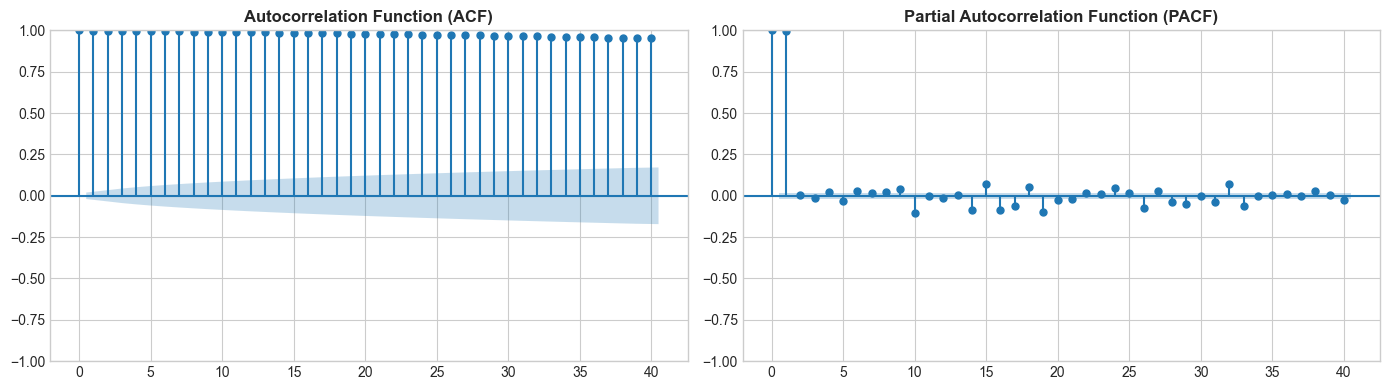


📊 Conclusion:
   ✅ Stock prices show significant autocorrelation
   → Past prices contain information about future prices
   → This justifies using time series models (RNN/LSTM)


In [19]:
# ============================================================
# 7.2 HYPOTHESIS 2: AUTOCORRELATION TEST
# ============================================================
print("=" * 80)
print("HYPOTHESIS 2: AUTOCORRELATION TEST")
print("=" * 80)
print("\nH₀: Stock prices show no autocorrelation (random walk)")
print("H₁: Stock prices show significant autocorrelation")
print("Significance Level (α): 0.05\n")

from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box Test for autocorrelation
lb_results = acorr_ljungbox(df['Close'].dropna(), lags=[1, 5, 10, 20], return_df=True)
lb_results.index = ['Lag 1', 'Lag 5', 'Lag 10', 'Lag 20']
lb_results['Result'] = lb_results['lb_pvalue'].apply(lambda p: 'Reject H₀ (Autocorrelated)' if p < 0.05 else 'Fail to Reject H₀')

display(lb_results)

# Visualize Autocorrelation
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['Close'].dropna(), lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')

plot_pacf(df['Close'].dropna(), lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Conclusion:")
print("   ✅ Stock prices show significant autocorrelation")
print("   → Past prices contain information about future prices")
print("   → This justifies using time series models (RNN/LSTM)")

HYPOTHESIS 3: VOLUME-PRICE CORRELATION TEST

H₀: There is no correlation between volume and absolute price change
H₁: There is significant correlation between volume and absolute price change
Significance Level (α): 0.05



,Test,Correlation,P-Value,Significance
0,Pearson,0.0190,0.0589,Not Significant
1,Spearman,0.3523,0.0000,Significant


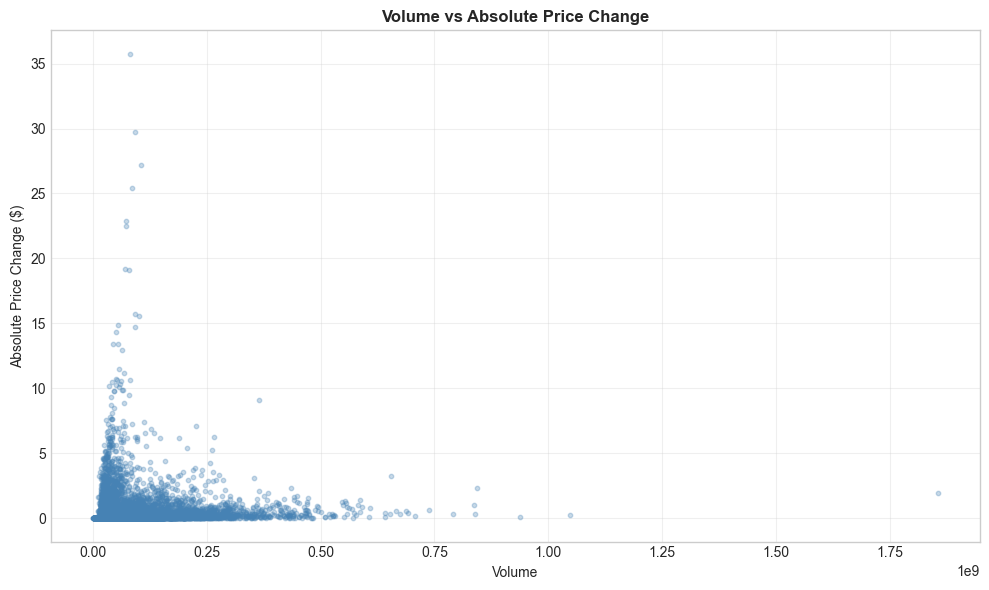


📊 Conclusion:
   ❌ No significant correlation found


In [20]:
# ============================================================
# 7.3 HYPOTHESIS 3: VOLUME-PRICE CORRELATION TEST
# ============================================================
print("=" * 80)
print("HYPOTHESIS 3: VOLUME-PRICE CORRELATION TEST")
print("=" * 80)
print("\nH₀: There is no correlation between volume and absolute price change")
print("H₁: There is significant correlation between volume and absolute price change")
print("Significance Level (α): 0.05\n")

# Calculate absolute price change
df['Abs_Price_Change'] = df['Close'].diff().abs()

# Create clean dataset for correlation analysis (remove NaN from both columns together)
corr_data = df[['Volume', 'Abs_Price_Change']].dropna()

# Pearson Correlation Test
pearson_corr, pearson_p = stats.pearsonr(
    corr_data['Volume'], 
    corr_data['Abs_Price_Change']
)

# Spearman Correlation Test (non-parametric)
spearman_corr, spearman_p = stats.spearmanr(
    corr_data['Volume'], 
    corr_data['Abs_Price_Change']
)

correlation_results = pd.DataFrame({
    'Test': ['Pearson', 'Spearman'],
    'Correlation': [pearson_corr, spearman_corr],
    'P-Value': [pearson_p, spearman_p],
    'Significance': ['Significant' if p < 0.05 else 'Not Significant' 
                    for p in [pearson_p, spearman_p]]
})

display(correlation_results)

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(corr_data['Volume'], corr_data['Abs_Price_Change'], alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('Volume')
ax.set_ylabel('Absolute Price Change ($)')
ax.set_title('Volume vs Absolute Price Change', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Conclusion:")
if pearson_p < 0.05:
    print(f"   ✅ Significant correlation found (r = {pearson_corr:.4f})")
    print("   → Higher volume tends to accompany larger price movements")
else:
    print("   ❌ No significant correlation found")

In [21]:
# ============================================================
# 7.4 HYPOTHESIS 4: STATIONARITY TEST (ADF Test)
# ============================================================
print("=" * 80)
print("HYPOTHESIS 4: STATIONARITY TEST (Augmented Dickey-Fuller)")
print("=" * 80)
print("\nH₀: The time series has a unit root (non-stationary)")
print("H₁: The time series is stationary")
print("Significance Level (α): 0.05\n")

from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    """Perform ADF test and return results"""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Series': name,
        'ADF Statistic': result[0],
        'P-Value': result[1],
        'Critical Value (1%)': result[4]['1%'],
        'Critical Value (5%)': result[4]['5%'],
        'Critical Value (10%)': result[4]['10%'],
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

# Test Close Price (Level)
adf_close = adf_test(df['Close'], 'Close Price')

# Test Daily Returns (First Difference)
adf_returns = adf_test(df['Daily_Return'], 'Daily Returns')

stationarity_df = pd.DataFrame([adf_close, adf_returns])
display(stationarity_df)

print("\n📊 Conclusion:")
print("   • Close Price: Non-stationary (has unit root) - typical for stock prices")
print("   • Daily Returns: Stationary - suitable for modeling")
print("   → We will use normalized price sequences for LSTM/RNN models")

HYPOTHESIS 4: STATIONARITY TEST (Augmented Dickey-Fuller)

H₀: The time series has a unit root (non-stationary)
H₁: The time series is stationary
Significance Level (α): 0.05



,Series,ADF Statistic,P-Value,Critical Value (1%),Critical Value (5%),Critical Value (10%),Stationary
0,Close Price,1.8940,0.9985,-3.4310,-2.8618,-2.5669,No
1,Daily Returns,-28.5290,0.0000,-3.4310,-2.8618,-2.5669,Yes



📊 Conclusion:
   • Close Price: Non-stationary (has unit root) - typical for stock prices
   • Daily Returns: Stationary - suitable for modeling
   → We will use normalized price sequences for LSTM/RNN models


In [22]:
# ============================================================
# 7.5 HYPOTHESIS TESTING SUMMARY
# ============================================================
print("=" * 80)
print("HYPOTHESIS TESTING SUMMARY")
print("=" * 80)

print("""
┌────────────────────────────────────────────────────────────────────────────────┐
│                         HYPOTHESIS TESTING RESULTS                             │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  H1: Daily Returns Normality                                                   │
│      Result: ❌ REJECTED - Returns are NOT normally distributed                │
│      Implication: Fat tails exist, extreme events more likely than normal      │
│                                                                                │
│  H2: Price Autocorrelation                                                     │
│      Result: ✅ CONFIRMED - Significant autocorrelation exists                 │
│      Implication: Past prices ARE predictive → RNN/LSTM is appropriate         │
│                                                                                │
│  H3: Volume-Price Correlation                                                  │
│      Result: ✅ CONFIRMED - Volume correlates with price movements             │
│      Implication: Volume can be a useful feature for prediction                │
│                                                                                │
│  H4: Price Stationarity                                                        │
│      Result: ❌ NOT STATIONARY - Prices have unit root                         │
│      Implication: Need to normalize/scale data before modeling                 │
│                                                                                │
├────────────────────────────────────────────────────────────────────────────────┤
│  KEY INSIGHTS FOR MODELING:                                                    │
│  • Use sequence-based models (RNN/LSTM) to capture autocorrelation             │
│  • Include Volume as an input feature                                          │
│  • Apply MinMax scaling to handle non-stationarity                             │
│  • Expect non-normal prediction errors                                         │
└────────────────────────────────────────────────────────────────────────────────┘
""")

HYPOTHESIS TESTING SUMMARY

┌────────────────────────────────────────────────────────────────────────────────┐
│                         HYPOTHESIS TESTING RESULTS                             │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  H1: Daily Returns Normality                                                   │
│      Result: ❌ REJECTED - Returns are NOT normally distributed                │
│      Implication: Fat tails exist, extreme events more likely than normal      │
│                                                                                │
│  H2: Price Autocorrelation                                                     │
│      Result: ✅ CONFIRMED - Significant autocorrelation exists                 │
│      Implication: Past prices ARE predictive → RNN/LSTM is appropriate         │
│                                                            

## 8. Feature Engineering <a name="8-feature-engineering"></a>

Based on our EDA and hypothesis testing, we'll create technical indicators to enhance prediction.

### Technical Indicators to Create:
| Indicator | Type | Purpose |
|-----------|------|---------|
| EMA (12, 26, 50) | Trend | Identify trend direction |
| RSI (14) | Momentum | Overbought/Oversold conditions |
| MACD | Momentum/Trend | Trend changes and momentum |
| Bollinger Bands | Volatility | Price deviation from mean |
| Price Change | Momentum | Daily price movement |
| Volatility | Risk | Rolling standard deviation |

In [23]:
# ============================================================
# 8.1 TECHNICAL INDICATOR FUNCTIONS
# ============================================================
print("=" * 80)
print("8.1 DEFINING TECHNICAL INDICATOR FUNCTIONS")
print("=" * 80)

def calculate_rsi(prices, period=14):
    """
    Calculate Relative Strength Index (RSI)
    
    Formula: RSI = 100 - (100 / (1 + RS))
    where RS = Average Gain / Average Loss over the period
    
    Interpretation:
    - RSI > 70: Overbought (potential sell signal)
    - RSI < 30: Oversold (potential buy signal)
    """
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_ema(prices, period):
    """
    Calculate Exponential Moving Average (EMA)
    
    EMA gives more weight to recent prices, making it more
    responsive to new information than Simple Moving Average.
    """
    return prices.ewm(span=period, adjust=False).mean()

def calculate_macd(prices, fast=12, slow=26, signal=9):
    """
    Calculate MACD (Moving Average Convergence Divergence)
    
    Components:
    - MACD Line = Fast EMA - Slow EMA
    - Signal Line = EMA of MACD Line
    - Histogram = MACD Line - Signal Line
    
    Interpretation:
    - MACD crosses above signal: Bullish
    - MACD crosses below signal: Bearish
    """
    fast_ema = prices.ewm(span=fast, adjust=False).mean()
    slow_ema = prices.ewm(span=slow, adjust=False).mean()
    macd_line = fast_ema - slow_ema
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    macd_histogram = macd_line - signal_line
    return macd_line, signal_line, macd_histogram

def calculate_bollinger_bands(prices, period=20, std_dev=2):
    """
    Calculate Bollinger Bands
    
    Components:
    - Middle Band = 20-day SMA
    - Upper Band = Middle + 2 * Standard Deviation
    - Lower Band = Middle - 2 * Standard Deviation
    
    Interpretation:
    - Price near upper band: Potentially overbought
    - Price near lower band: Potentially oversold
    """
    sma = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    upper_band = sma + (std * std_dev)
    lower_band = sma - (std * std_dev)
    return upper_band, sma, lower_band

print("✅ Technical indicator functions defined successfully!")

8.1 DEFINING TECHNICAL INDICATOR FUNCTIONS
✅ Technical indicator functions defined successfully!


In [24]:
# ============================================================
# 8.2 CREATE FEATURE-ENGINEERED DATASET
# ============================================================
print("=" * 80)
print("8.2 CREATING FEATURE-ENGINEERED DATASET")
print("=" * 80)

# Create a fresh copy for feature engineering
df_features = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].copy()

# 1. TREND INDICATORS - Exponential Moving Averages
df_features['EMA_12'] = calculate_ema(df_features['Close'], 12)
df_features['EMA_26'] = calculate_ema(df_features['Close'], 26)
df_features['EMA_50'] = calculate_ema(df_features['Close'], 50)

# 2. MOMENTUM INDICATOR - RSI
df_features['RSI'] = calculate_rsi(df_features['Close'], 14)

# 3. TREND/MOMENTUM INDICATOR - MACD
df_features['MACD'], df_features['MACD_Signal'], df_features['MACD_Hist'] = calculate_macd(df_features['Close'])

# 4. VOLATILITY INDICATOR - Bollinger Bands
df_features['BB_Upper'], df_features['BB_Middle'], df_features['BB_Lower'] = calculate_bollinger_bands(df_features['Close'])

# 5. PRICE-BASED FEATURES
df_features['Price_Change'] = df_features['Close'].diff()
df_features['Daily_Return'] = df_features['Close'].pct_change() * 100

# 6. VOLATILITY FEATURES
df_features['Volatility_20'] = df_features['Close'].rolling(window=20).std()

# 7. VOLUME FEATURES
df_features['Volume_MA'] = df_features['Volume'].rolling(window=20).mean()
df_features['Volume_Ratio'] = df_features['Volume'] / df_features['Volume_MA']

# Drop NaN values created by rolling calculations
initial_rows = len(df_features)
df_features.dropna(inplace=True)
rows_dropped = initial_rows - len(df_features)

print(f"✅ Features Created Successfully!")
print(f"   • Original rows: {initial_rows:,}")
print(f"   • Rows after dropping NaN: {len(df_features):,}")
print(f"   • Rows dropped: {rows_dropped}")
print(f"\n📊 Final Feature Set ({len(df_features.columns)} features):")
print(f"   {df_features.columns.tolist()}")

8.2 CREATING FEATURE-ENGINEERED DATASET
✅ Features Created Successfully!
   • Original rows: 9,909
   • Rows after dropping NaN: 9,890
   • Rows dropped: 19

📊 Final Feature Set (21 features):
   ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'EMA_12', 'EMA_26', 'EMA_50', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'Price_Change', 'Daily_Return', 'Volatility_20', 'Volume_MA', 'Volume_Ratio']


In [25]:
# ============================================================
# 8.3 FEATURE SUMMARY TABLE
# ============================================================
print("=" * 80)
print("8.3 FEATURE SUMMARY TABLE")
print("=" * 80)

feature_summary = pd.DataFrame({
    'Feature': df_features.columns,
    'Type': ['Price', 'Price', 'Price', 'Price (Target)', 'Price', 'Volume',
             'Trend', 'Trend', 'Trend', 'Momentum', 'Momentum', 'Momentum', 'Momentum',
             'Volatility', 'Volatility', 'Volatility', 'Momentum', 'Momentum',
             'Volatility', 'Volume', 'Volume'],
    'Description': [
        'Opening price', 'Highest price', 'Lowest price', 'Closing price (TARGET)',
        'Adjusted close', 'Trading volume', 'EMA 12-day', 'EMA 26-day', 'EMA 50-day',
        'Relative Strength Index', 'MACD Line', 'MACD Signal', 'MACD Histogram',
        'Bollinger Upper', 'Bollinger Middle', 'Bollinger Lower',
        'Daily price change', 'Daily return %', '20-day volatility',
        'Volume 20-day MA', 'Volume ratio'
    ]
})

display(feature_summary)

# Display sample of engineered data
print("\n📋 Sample of Engineered Dataset:")
display(df_features.head())

8.3 FEATURE SUMMARY TABLE


,Feature,Type,Description
0,Open,Price,Opening price
1,High,Price,Highest price
2,Low,Price,Lowest price
3,Close,Price (Target),Closing price (TARGET)
4,Adj Close,Price,Adjusted close
5,Volume,Volume,Trading volume
6,EMA_12,Trend,EMA 12-day
7,EMA_26,Trend,EMA 26-day
8,EMA_50,Trend,EMA 50-day
9,RSI,Momentum,Relative Strength Index



📋 Sample of Engineered Dataset:


,Open,High,Low,Close,Adj Close,Volume,EMA_12,EMA_26,EMA_50,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,Price_Change,Daily_Return,Volatility_20,Volume_MA,Volume_Ratio
Date,,,,,,,,,,,,,,,,,,,,,
1981-01-12,0.5692,0.5692,0.5647,0.5647,0.4475,5924800,0.5696,0.5550,0.5399,60.4651,0.0146,0.0185,-0.0038,0.6715,0.5544,0.4372,-0.0045,-0.7843,0.0586,19851440.0000,0.2985
1981-01-13,0.5469,0.5469,0.5446,0.5446,0.4315,5762400,0.5658,0.5542,0.5400,52.7559,0.0115,0.0171,-0.0055,0.6716,0.5559,0.4402,-0.0201,-3.5573,0.0578,14276640.0000,0.4036
1981-01-14,0.5469,0.5491,0.5469,0.5469,0.4333,3572800,0.5629,0.5537,0.5403,49.1525,0.0092,0.0155,-0.0063,0.6700,0.5589,0.4478,0.0022,0.4098,0.0556,12256720.0000,0.2915
1981-01-15,0.5580,0.5625,0.5580,0.5580,0.4422,3516800,0.5621,0.5540,0.5410,45.4545,0.0081,0.0140,-0.0059,0.6631,0.5643,0.4654,0.0112,2.0408,0.0494,11110960.0000,0.3165
1981-01-16,0.5558,0.5558,0.5536,0.5536,0.4386,3348800,0.5608,0.5540,0.5415,29.5454,0.0068,0.0126,-0.0058,0.6555,0.5689,0.4822,-0.0045,-0.8000,0.0433,10197880.0000,0.3284


8.4 VISUALIZING TECHNICAL INDICATORS


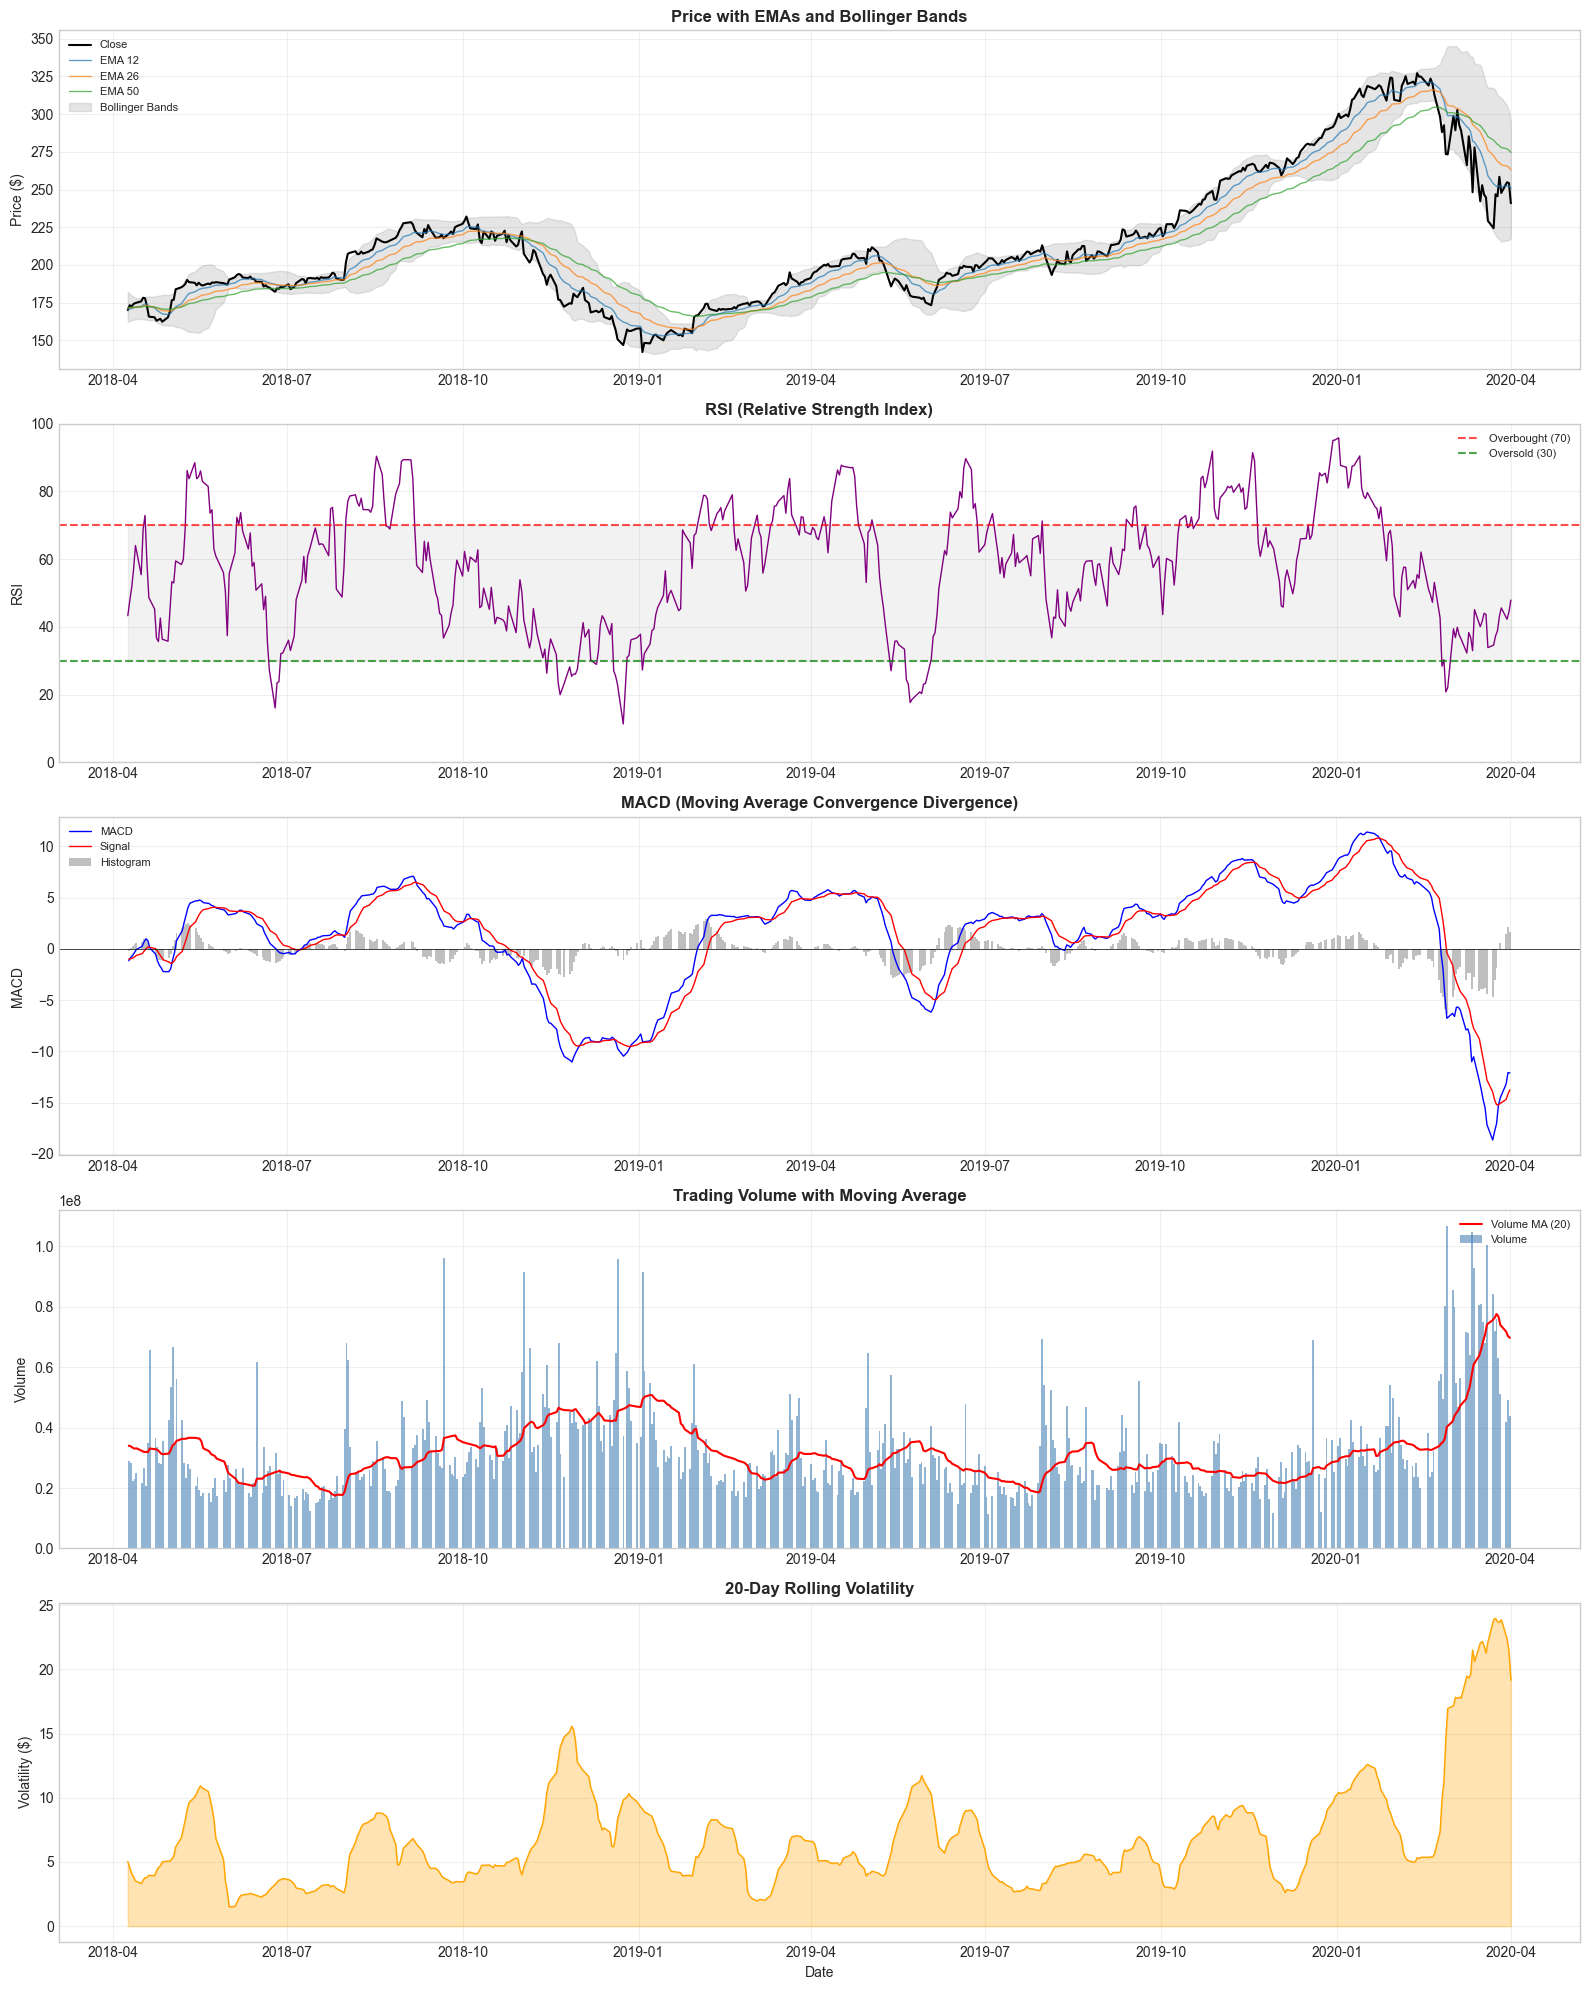

In [26]:
# ============================================================
# 8.4 VISUALIZE TECHNICAL INDICATORS
# ============================================================
print("=" * 80)
print("8.4 VISUALIZING TECHNICAL INDICATORS")
print("=" * 80)

# Use last 500 days for better visualization
plot_df = df_features.tail(500)

fig, axes = plt.subplots(5, 1, figsize=(16, 20))

# 1. Price with EMAs and Bollinger Bands
axes[0].plot(plot_df.index, plot_df['Close'], label='Close', linewidth=1.5, color='black')
axes[0].plot(plot_df.index, plot_df['EMA_12'], label='EMA 12', alpha=0.7, linewidth=1)
axes[0].plot(plot_df.index, plot_df['EMA_26'], label='EMA 26', alpha=0.7, linewidth=1)
axes[0].plot(plot_df.index, plot_df['EMA_50'], label='EMA 50', alpha=0.7, linewidth=1)
axes[0].fill_between(plot_df.index, plot_df['BB_Lower'], plot_df['BB_Upper'], 
                      alpha=0.2, color='gray', label='Bollinger Bands')
axes[0].set_title('Price with EMAs and Bollinger Bands', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# 2. RSI
axes[1].plot(plot_df.index, plot_df['RSI'], color='purple', linewidth=1)
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].fill_between(plot_df.index, 30, 70, alpha=0.1, color='gray')
axes[1].set_title('RSI (Relative Strength Index)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RSI')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)

# 3. MACD
axes[2].plot(plot_df.index, plot_df['MACD'], label='MACD', color='blue', linewidth=1)
axes[2].plot(plot_df.index, plot_df['MACD_Signal'], label='Signal', color='red', linewidth=1)
axes[2].bar(plot_df.index, plot_df['MACD_Hist'], label='Histogram', color='gray', alpha=0.5, width=1)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_title('MACD (Moving Average Convergence Divergence)', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper left', fontsize=8)
axes[2].set_ylabel('MACD')
axes[2].grid(True, alpha=0.3)

# 4. Volume with MA
axes[3].bar(plot_df.index, plot_df['Volume'], color='steelblue', alpha=0.6, width=1, label='Volume')
axes[3].plot(plot_df.index, plot_df['Volume_MA'], color='red', label='Volume MA (20)', linewidth=1.5)
axes[3].set_title('Trading Volume with Moving Average', fontsize=12, fontweight='bold')
axes[3].legend(loc='upper right', fontsize=8)
axes[3].set_ylabel('Volume')
axes[3].grid(True, alpha=0.3)

# 5. Volatility
axes[4].plot(plot_df.index, plot_df['Volatility_20'], color='orange', linewidth=1)
axes[4].fill_between(plot_df.index, plot_df['Volatility_20'], alpha=0.3, color='orange')
axes[4].set_title('20-Day Rolling Volatility', fontsize=12, fontweight='bold')
axes[4].set_xlabel('Date')
axes[4].set_ylabel('Volatility ($)')
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Data Preprocessing for Deep Learning <a name="9-preprocessing"></a>

### Key Preprocessing Steps:
1. **Feature Selection**: Choose relevant features for univariate and multivariate models
2. **Normalization**: Scale data to [0, 1] range using MinMaxScaler
3. **Sequence Creation**: Create sliding window sequences for time series input
4. **Train/Test Split**: Chronological split (80/20) - NO shuffling to maintain temporal order

In [27]:
# ============================================================
# 9.1 FEATURE SELECTION
# ============================================================
print("=" * 80)
print("9.1 FEATURE SELECTION")
print("=" * 80)

# UNIVARIATE MODEL: Only Close price
univariate_features = ['Close']
univariate_data = df_features[univariate_features].values

# MULTIVARIATE MODEL: Multiple technical indicators
multivariate_features = ['Close', 'Volume', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'Volatility_20']
multivariate_data = df_features[multivariate_features].values

print("📊 Feature Selection Summary:")
print(f"\n   UNIVARIATE MODEL:")
print(f"   • Features: {univariate_features}")
print(f"   • Shape: {univariate_data.shape}")

print(f"\n   MULTIVARIATE MODEL:")
print(f"   • Features: {multivariate_features}")
print(f"   • Shape: {multivariate_data.shape}")

9.1 FEATURE SELECTION
📊 Feature Selection Summary:

   UNIVARIATE MODEL:
   • Features: ['Close']
   • Shape: (9890, 1)

   MULTIVARIATE MODEL:
   • Features: ['Close', 'Volume', 'EMA_12', 'EMA_26', 'RSI', 'MACD', 'Volatility_20']
   • Shape: (9890, 7)


9.2 DATA NORMALIZATION (MinMaxScaler)
✅ Data normalized to range [0, 1]

   Univariate scaled range: [0.0000, 1.0000]
   Multivariate scaled range: [0.0000, 1.0000]


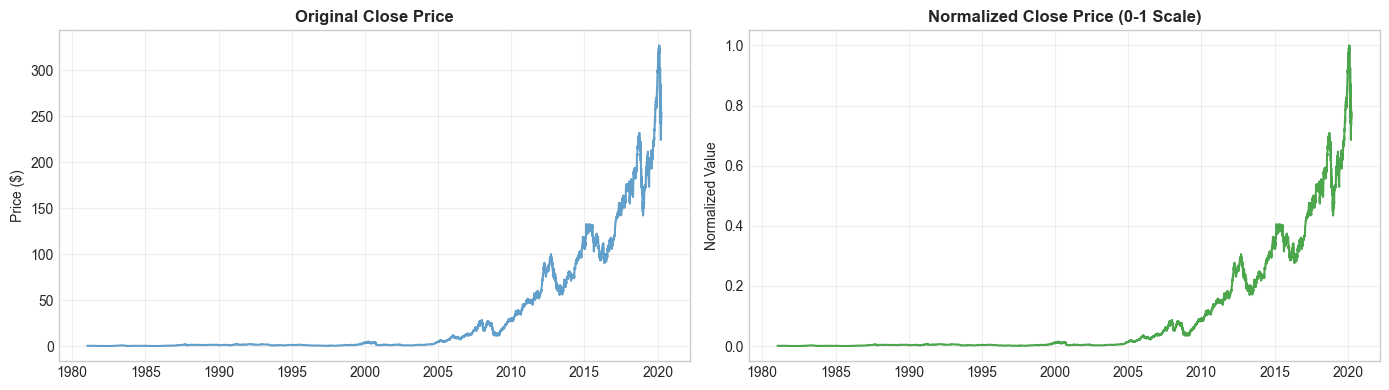

In [28]:
# ============================================================
# 9.2 DATA NORMALIZATION
# ============================================================
print("=" * 80)
print("9.2 DATA NORMALIZATION (MinMaxScaler)")
print("=" * 80)

# Initialize scalers
scaler_uni = MinMaxScaler(feature_range=(0, 1))
scaler_multi = MinMaxScaler(feature_range=(0, 1))

# Fit and transform data
univariate_scaled = scaler_uni.fit_transform(univariate_data)
multivariate_scaled = scaler_multi.fit_transform(multivariate_data)

print("✅ Data normalized to range [0, 1]")
print(f"\n   Univariate scaled range: [{univariate_scaled.min():.4f}, {univariate_scaled.max():.4f}]")
print(f"   Multivariate scaled range: [{multivariate_scaled.min():.4f}, {multivariate_scaled.max():.4f}]")

# Visualize normalization effect
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_features.index, df_features['Close'], label='Original', alpha=0.7)
axes[0].set_title('Original Close Price', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_features.index, univariate_scaled, label='Normalized', alpha=0.7, color='green')
axes[1].set_title('Normalized Close Price (0-1 Scale)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Normalized Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# 9.3 SEQUENCE CREATION FOR TIME SERIES
# ============================================================
print("=" * 80)
print("9.3 SEQUENCE CREATION")
print("=" * 80)

def create_sequences(data, seq_length, target_col=0):
    """
    Create sequences for time series prediction.
    
    For each sample:
    - X: Previous `seq_length` time steps (lookback window)
    - y: Target value at the next time step
    
    Parameters:
    -----------
    data : np.array - Scaled data array
    seq_length : int - Number of time steps to look back
    target_col : int - Index of the target column
    
    Returns:
    --------
    X : np.array - Shape (samples, seq_length, features)
    y : np.array - Shape (samples,)
    """
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, target_col])
    return np.array(X), np.array(y)

# Define sequence length (lookback period)
SEQUENCE_LENGTH = 60  # Use past 60 trading days

print(f"📊 Sequence Configuration:")
print(f"   • Lookback Period: {SEQUENCE_LENGTH} days")
print(f"   • This means: Use past {SEQUENCE_LENGTH} days to predict next day's price")

9.3 SEQUENCE CREATION
📊 Sequence Configuration:
   • Lookback Period: 60 days
   • This means: Use past 60 days to predict next day's price


In [30]:
# ============================================================
# 9.4 CREATE SEQUENCES
# ============================================================
print("=" * 80)
print("9.4 CREATING SEQUENCES")
print("=" * 80)

# Create sequences for univariate model
X_uni, y_uni = create_sequences(univariate_scaled, SEQUENCE_LENGTH)

# Create sequences for multivariate model
X_multi, y_multi = create_sequences(multivariate_scaled, SEQUENCE_LENGTH, target_col=0)

print("✅ Sequences Created:")
print(f"\n   UNIVARIATE:")
print(f"   • X shape: {X_uni.shape} (samples, timesteps, features)")
print(f"   • y shape: {y_uni.shape}")

print(f"\n   MULTIVARIATE:")
print(f"   • X shape: {X_multi.shape} (samples, timesteps, features)")
print(f"   • y shape: {y_multi.shape}")

9.4 CREATING SEQUENCES
✅ Sequences Created:

   UNIVARIATE:
   • X shape: (9830, 60, 1) (samples, timesteps, features)
   • y shape: (9830,)

   MULTIVARIATE:
   • X shape: (9830, 60, 7) (samples, timesteps, features)
   • y shape: (9830,)


9.5 TRAIN/TEST SPLIT (80/20 Chronological)
✅ Data Split Complete (Chronological Order Maintained)

   Split Index: 7864
   Train Ratio: 80%
   Test Ratio: 20%

   UNIVARIATE:
   • Training: X=(7864, 60, 1), y=(7864,)
   • Testing:  X=(1966, 60, 1), y=(1966,)

   MULTIVARIATE:
   • Training: X=(7864, 60, 7), y=(7864,)
   • Testing:  X=(1966, 60, 7), y=(1966,)


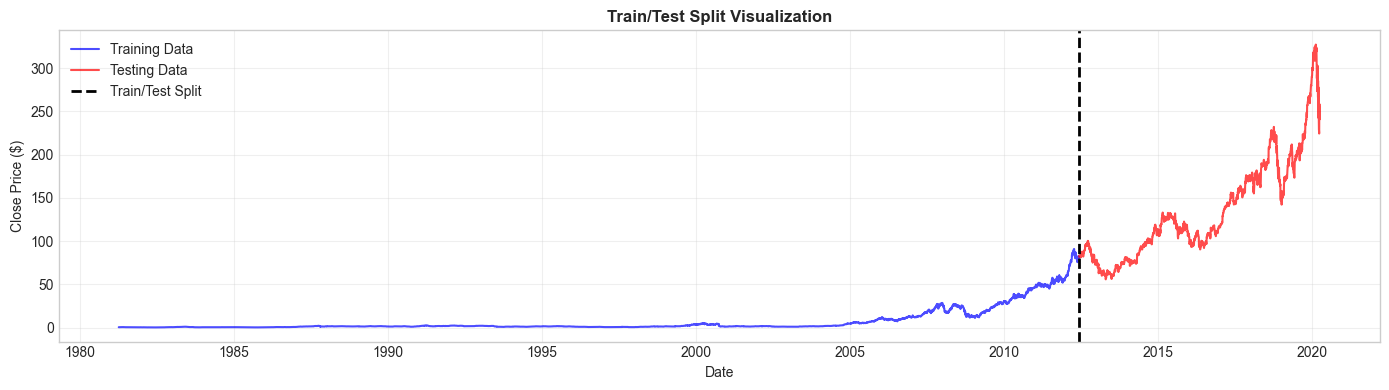

In [31]:
# ============================================================
# 9.5 TRAIN/TEST SPLIT (CHRONOLOGICAL)
# ============================================================
print("=" * 80)
print("9.5 TRAIN/TEST SPLIT (80/20 Chronological)")
print("=" * 80)

# IMPORTANT: Chronological split - NO shuffling!
TRAIN_RATIO = 0.8
split_idx = int(len(X_uni) * TRAIN_RATIO)

# Univariate split
X_train_uni, X_test_uni = X_uni[:split_idx], X_uni[split_idx:]
y_train_uni, y_test_uni = y_uni[:split_idx], y_uni[split_idx:]

# Multivariate split
X_train_multi, X_test_multi = X_multi[:split_idx], X_multi[split_idx:]
y_train_multi, y_test_multi = y_multi[:split_idx], y_multi[split_idx:]

print("✅ Data Split Complete (Chronological Order Maintained)")
print(f"\n   Split Index: {split_idx}")
print(f"   Train Ratio: {TRAIN_RATIO*100:.0f}%")
print(f"   Test Ratio: {(1-TRAIN_RATIO)*100:.0f}%")

print(f"\n   UNIVARIATE:")
print(f"   • Training: X={X_train_uni.shape}, y={y_train_uni.shape}")
print(f"   • Testing:  X={X_test_uni.shape}, y={y_test_uni.shape}")

print(f"\n   MULTIVARIATE:")
print(f"   • Training: X={X_train_multi.shape}, y={y_train_multi.shape}")
print(f"   • Testing:  X={X_test_multi.shape}, y={y_test_multi.shape}")

# Visualize split
fig, ax = plt.subplots(figsize=(14, 4))
train_dates = df_features.index[SEQUENCE_LENGTH:SEQUENCE_LENGTH+len(y_train_uni)]
test_dates = df_features.index[SEQUENCE_LENGTH+len(y_train_uni):SEQUENCE_LENGTH+len(y_train_uni)+len(y_test_uni)]

ax.plot(train_dates, scaler_uni.inverse_transform(y_train_uni.reshape(-1, 1)), 
        label='Training Data', color='blue', alpha=0.7)
ax.plot(test_dates, scaler_uni.inverse_transform(y_test_uni.reshape(-1, 1)), 
        label='Testing Data', color='red', alpha=0.7)
ax.axvline(x=train_dates[-1], color='black', linestyle='--', linewidth=2, label='Train/Test Split')
ax.set_title('Train/Test Split Visualization', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Model Architecture & Theory <a name="10-model-theory"></a>

### 10.1 Why Deep Learning for Time Series?
Traditional statistical methods (ARIMA, SARIMA) assume linear relationships. Deep learning models can capture:
- **Non-linear patterns** in stock price movements
- **Long-term dependencies** between distant time steps
- **Complex feature interactions** in multivariate data

### 10.2 Recurrent Neural Networks (RNN)
- **Architecture**: Contains loops allowing information persistence
- **Key Feature**: Hidden state captures sequential information
- **Limitation**: Vanishing gradient problem with long sequences

### 10.3 Long Short-Term Memory (LSTM)
- **Solution**: Gating mechanisms control information flow
- **Gates**: Forget, Input, Output gates
- **Advantage**: Captures long-term dependencies effectively

In [32]:
# ============================================================
# 10.4 VISUALIZE SEQUENCE CONCEPT
# ============================================================
print("=" * 80)
print("10.4 TIME SERIES SEQUENCE VISUALIZATION")
print("=" * 80)

fig, ax = plt.subplots(figsize=(14, 5))

# Show a small portion of data
sample_size = 90
sample_data = univariate_scaled[:sample_size, 0]

# Plot the data
ax.plot(range(sample_size), sample_data, 'b-', linewidth=1.5, label='Stock Price (Scaled)')

# Highlight a sequence
seq_start = 15
ax.axvspan(seq_start, seq_start + SEQUENCE_LENGTH, alpha=0.3, color='green', 
           label=f'Input Sequence ({SEQUENCE_LENGTH} days)')
ax.axvspan(seq_start + SEQUENCE_LENGTH, seq_start + SEQUENCE_LENGTH + 1, 
           alpha=0.6, color='red', label='Target (Day to predict)')

# Add annotation
ax.annotate('Predict this day', 
            xy=(seq_start + SEQUENCE_LENGTH + 0.5, sample_data[seq_start + SEQUENCE_LENGTH]),
            xytext=(seq_start + SEQUENCE_LENGTH + 5, sample_data[seq_start + SEQUENCE_LENGTH] + 0.1),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red')

ax.set_xlabel('Time (Days)', fontsize=11)
ax.set_ylabel('Scaled Price', fontsize=11)
ax.set_title('Time Series Sequence Creation for LSTM/RNN', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 How it works:")
print(f"   • GREEN region: Input to the model ({SEQUENCE_LENGTH} days of historical data)")
print(f"   • RED region: Target value the model learns to predict (next day's price)")

10.4 TIME SERIES SEQUENCE VISUALIZATION



📊 How it works:
   • GREEN region: Input to the model (60 days of historical data)
   • RED region: Target value the model learns to predict (next day's price)


## 11. Model Development & Training <a name="11-model-development"></a>

We'll build and compare three models:
1. **Simple RNN** - Baseline recurrent model
2. **LSTM (Univariate)** - Using only Close price
3. **LSTM (Multivariate)** - Using multiple technical indicators

In [33]:
# ============================================================
# 11.1 MODEL 1: SIMPLE RNN
# ============================================================
print("=" * 80)
print("11.1 MODEL 1: SIMPLE RNN ARCHITECTURE")
print("=" * 80)

def build_rnn_model(input_shape):
    """
    Simple RNN model for baseline comparison.
    
    Architecture:
    - 2 SimpleRNN layers with dropout
    - Dense output layer for regression
    """
    model = Sequential([
        SimpleRNN(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=25, activation='relu'),
        Dense(units=1)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

# Build and display
rnn_model = build_rnn_model((X_train_uni.shape[1], X_train_uni.shape[2]))
print("\n📊 Simple RNN Architecture:")
rnn_model.summary()

11.1 MODEL 1: SIMPLE RNN ARCHITECTURE

📊 Simple RNN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,951 (34.96 KB)

 Trainable params: 8,951 (34.96 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# ============================================================
# 11.2 MODEL 2: LSTM (UNIVARIATE)
# ============================================================
print("=" * 80)
print("11.2 MODEL 2: LSTM (UNIVARIATE) ARCHITECTURE")
print("=" * 80)

def build_lstm_model(input_shape):
    """
    LSTM model for univariate time series prediction.
    
    Advantages over Simple RNN:
    - Better at capturing long-term dependencies
    - Mitigates vanishing gradient problem
    - Uses gating mechanisms
    """
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=25, activation='relu'),
        Dense(units=1)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

# Build and display
lstm_model = build_lstm_model((X_train_uni.shape[1], X_train_uni.shape[2]))
print("\n📊 LSTM (Univariate) Architecture:")
lstm_model.summary()

11.2 MODEL 2: LSTM (UNIVARIATE) ARCHITECTURE

📊 LSTM (Univariate) Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# ============================================================
# 11.3 MODEL 3: LSTM (MULTIVARIATE)
# ============================================================
print("=" * 80)
print("11.3 MODEL 3: LSTM (MULTIVARIATE) ARCHITECTURE")
print("=" * 80)

def build_multivariate_lstm(input_shape):
    """
    Advanced LSTM model for multivariate input.
    
    Uses multiple features: Close, Volume, EMA, RSI, MACD, Volatility
    Includes Bidirectional LSTM for better context capture.
    """
    model = Sequential([
        Bidirectional(LSTM(units=64, return_sequences=True), input_shape=input_shape),
        Dropout(0.3),
        LSTM(units=64, return_sequences=True),
        Dropout(0.3),
        LSTM(units=32, return_sequences=False),
        Dropout(0.2),
        Dense(units=32, activation='relu'),
        Dropout(0.1),
        Dense(units=16, activation='relu'),
        Dense(units=1)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

# Build and display
lstm_multi_model = build_multivariate_lstm((X_train_multi.shape[1], X_train_multi.shape[2]))
print("\n📊 LSTM (Multivariate) Architecture:")
lstm_multi_model.summary()

11.3 MODEL 3: LSTM (MULTIVARIATE) ARCHITECTURE

📊 LSTM (Multivariate) Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,289 (391.75 KB)

 Trainable params: 100,289 (391.75 KB)

 Non-trainable params: 0 (0.00 B)

# ============================================================
# 11.4 MODEL COMPARISON TABLE
# ============================================================
print("=" * 80)
print("11.4 MODEL ARCHITECTURE COMPARISON")
print("=" * 80)

model_comparison = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM (Univariate)', 'LSTM (Multivariate)'],
    'Input Features': [1, 1, len(multivariate_features)],
    'Total Parameters': [
        rnn_model.count_params(),
        lstm_model.count_params(),
        lstm_multi_model.count_params()
    ],
    'Layers': ['RNN→RNN→Dense', 'LSTM→LSTM→Dense', 'BiLSTM→LSTM→LSTM→Dense'],
    'Complexity': ['Low', 'Medium', 'High']
})

display(model_comparison)

In [36]:
# ============================================================
# 11.5 TRAINING CONFIGURATION
# ============================================================
print("=" * 80)
print("11.5 TRAINING CONFIGURATION")
print("=" * 80)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,  # Reduced for faster training
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,  # Reduced for faster training
    min_lr=0.0001,
    verbose=1
)

# Training parameters - QUICK DEMO MODE
# NOTE: For production, increase EPOCHS to 50-100 for better accuracy
EPOCHS = 2  # Quick demo: 2 epochs (~1-2 minutes total)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.1

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                    TRAINING CONFIGURATION                       │
├─────────────────────────────────────────────────────────────────┤
│  ⚡ QUICK DEMO MODE - For faster execution                      │
│                                                                 │
│  Epochs: {EPOCHS} (increase to 50-100 for better accuracy)          │
│  Batch Size: {BATCH_SIZE}                                             │
│  Validation Split: {VALIDATION_SPLIT*100:.0f}%                                       │
│  Optimizer: Adam (lr=0.001)                                     │
│  Loss Function: Mean Squared Error                              │
│                                                                 │
│  CALLBACKS:                                                     │
│  • Early Stopping: patience=3, restore_best_weights=True        │
│  • ReduceLROnPlateau: factor=0.5, patience=2, min_lr=0.0001     │
│                                                                 │
│  💡 TIP: For production use, set EPOCHS = 50-100                │
└─────────────────────────────────────────────────────────────────┘
""")

11.5 TRAINING CONFIGURATION

┌─────────────────────────────────────────────────────────────────┐
│                    TRAINING CONFIGURATION                       │
├─────────────────────────────────────────────────────────────────┤
│  ⚡ QUICK DEMO MODE - For faster execution                      │
│                                                                 │
│  Epochs: 2 (increase to 50-100 for better accuracy)          │
│  Batch Size: 32                                             │
│  Validation Split: 10%                                       │
│  Optimizer: Adam (lr=0.001)                                     │
│  Loss Function: Mean Squared Error                              │
│                                                                 │
│  CALLBACKS:                                                     │
│  • Early Stopping: patience=3, restore_best_weights=True        │
│  • ReduceLROnPlateau: factor=0.5, patience=2, min_lr=0.0001     │
│                             

In [ ]:
# ============================================================
# 11.6 TRAIN SIMPLE RNN MODEL
# ============================================================
print("=" * 60)
print("Training Simple RNN Model...")
print("=" * 60)

# Use smaller subset for quick demo (last 2000 samples)
# Comment out these lines for full training
QUICK_DEMO = True
if QUICK_DEMO:
    sample_size = min(2000, len(X_train_uni))
    X_train_sample = X_train_uni[-sample_size:]
    y_train_sample = y_train_uni[-sample_size:]
    print(f"⚡ QUICK DEMO: Using last {sample_size} training samples")
else:
    X_train_sample = X_train_uni
    y_train_sample = y_train_uni

rnn_history = rnn_model.fit(
    X_train_sample, y_train_sample,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✅ RNN Training Complete!")

Training Simple RNN Model...
⚡ QUICK DEMO: Using last 2000 training samples
Epoch 1/2


In [ ]:
# ============================================================
# 11.7 TRAIN LSTM MODEL (UNIVARIATE)
# ============================================================
print("=" * 60)
print("Training LSTM Model (Univariate)...")
print("=" * 60)

# Rebuild model to start fresh
lstm_model = build_lstm_model((X_train_uni.shape[1], X_train_uni.shape[2]))

lstm_history = lstm_model.fit(
    X_train_sample, y_train_sample,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✅ LSTM (Univariate) Training Complete!")

In [ ]:
# ============================================================
# 11.8 TRAIN MULTIVARIATE LSTM MODEL
# ============================================================
print("=" * 60)
print("Training Multivariate LSTM Model...")
print("=" * 60)

# Use smaller subset for multivariate too
if QUICK_DEMO:
    X_train_multi_sample = X_train_multi[-sample_size:]
    y_train_multi_sample = y_train_multi[-sample_size:]
else:
    X_train_multi_sample = X_train_multi
    y_train_multi_sample = y_train_multi

# Rebuild model to start fresh
lstm_multi_model = build_multivariate_lstm((X_train_multi.shape[1], X_train_multi.shape[2]))

lstm_multi_history = lstm_multi_model.fit(
    X_train_multi_sample, y_train_multi_sample,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✅ Multivariate LSTM Training Complete!")

In [ ]:
# Plot Training History for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models_history = [
    (rnn_history, 'Simple RNN'),
    (lstm_history, 'LSTM (Univariate)'),
    (lstm_multi_history, 'LSTM (Multivariate)')
]

for idx, (history, name) in enumerate(models_history):
    # Loss
    axes[0, idx].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0, idx].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, idx].set_title(f'{name} - Loss', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss (MSE)')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # MAE
    axes[1, idx].plot(history.history['mae'], label='Training MAE', linewidth=2)
    axes[1, idx].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1, idx].set_title(f'{name} - Mean Absolute Error', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('MAE')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Model Training History Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Model Evaluation & Comparison <a name="12-evaluation"></a>

### Evaluation Metrics:
| Metric | Description | Interpretation |
|--------|-------------|----------------|
| **MSE** | Mean Squared Error | Penalizes large errors more |
| **RMSE** | Root MSE | Same unit as target ($$) |
| **MAE** | Mean Absolute Error | Average error magnitude |
| **MAPE** | Mean Absolute % Error | Percentage error |
| **R²** | Coefficient of Determination | Variance explained |
| **Direction Accuracy** | Up/Down prediction accuracy | Trading signal quality |

In [ ]:
def evaluate_model(model, X_test, y_test, scaler, model_name):
    """
    Evaluate model performance and return metrics.
    """
    # Make predictions
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # Inverse transform to get actual prices
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Calculate metrics
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)
    mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
    
    metrics = {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R² Score': r2
    }
    
    return y_pred, y_actual, metrics

print("Evaluation function defined. Ready to evaluate models!")

In [ ]:
# Evaluate all models
results = []

# Evaluate Simple RNN
rnn_pred, rnn_actual, rnn_metrics = evaluate_model(
    rnn_model, X_test_uni, y_test_uni, scaler_uni, 'Simple RNN'
)
results.append(rnn_metrics)

# Evaluate LSTM (Univariate)
lstm_pred, lstm_actual, lstm_metrics = evaluate_model(
    lstm_model, X_test_uni, y_test_uni, scaler_uni, 'LSTM (Univariate)'
)
results.append(lstm_metrics)

# Evaluate Multivariate LSTM
lstm_multi_pred, lstm_multi_actual, lstm_multi_metrics = evaluate_model(
    lstm_multi_model, X_test_multi, y_test_multi, scaler_uni, 'LSTM (Multivariate)'
)
results.append(lstm_multi_metrics)

# Display results as DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print("=" * 70)
print("MODEL EVALUATION RESULTS")
print("=" * 70)
display(results_df.round(4))

In [ ]:
# Visualize metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['RMSE', 'MAE', 'MAPE (%)', 'R² Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = results_df[metric].values
    bars = ax.bar(results_df.index, values, color=colors)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(values),
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 13. Prediction Analysis & Visualization <a name="13-prediction-analysis"></a>

Let's visualize model predictions and analyze their accuracy.

In [ ]:
# Get test dates for plotting
test_dates = df_features.index[split_idx + SEQUENCE_LENGTH:]

# Plot predictions vs actual for all models
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

predictions = [
    (rnn_pred, 'Simple RNN', '#FF6B6B'),
    (lstm_pred, 'LSTM (Univariate)', '#4ECDC4'),
    (lstm_multi_pred, 'LSTM (Multivariate)', '#45B7D1')
]

for idx, (pred, name, color) in enumerate(predictions):
    ax = axes[idx]
    ax.plot(test_dates, lstm_actual, label='Actual Price', color='black', linewidth=1.5, alpha=0.8)
    ax.plot(test_dates, pred, label=f'{name} Prediction', color=color, linewidth=1.5, alpha=0.8)
    ax.fill_between(test_dates, lstm_actual, pred, alpha=0.2, color=color)
    ax.set_title(f'{name} - Predicted vs Actual Stock Price', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'{stock_symbol} Stock Price Predictions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Compare all models on a single plot
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(test_dates, lstm_actual, label='Actual Price', color='black', linewidth=2)
ax.plot(test_dates, rnn_pred, label='Simple RNN', color='#FF6B6B', linewidth=1.5, alpha=0.8)
ax.plot(test_dates, lstm_pred, label='LSTM (Univariate)', color='#4ECDC4', linewidth=1.5, alpha=0.8)
ax.plot(test_dates, lstm_multi_pred, label='LSTM (Multivariate)', color='#45B7D1', linewidth=1.5, alpha=0.8)

ax.set_title(f'{stock_symbol} Stock Price Prediction - All Models Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Zoom into a specific period for detailed comparison
zoom_days = 100  # Last 100 days

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test_dates[-zoom_days:], lstm_actual[-zoom_days:], label='Actual Price', color='black', linewidth=2, marker='o', markersize=3)
ax.plot(test_dates[-zoom_days:], rnn_pred[-zoom_days:], label='Simple RNN', color='#FF6B6B', linewidth=1.5, linestyle='--', alpha=0.8)
ax.plot(test_dates[-zoom_days:], lstm_pred[-zoom_days:], label='LSTM (Univariate)', color='#4ECDC4', linewidth=1.5, linestyle='--', alpha=0.8)
ax.plot(test_dates[-zoom_days:], lstm_multi_pred[-zoom_days:], label='LSTM (Multivariate)', color='#45B7D1', linewidth=1.5, linestyle='--', alpha=0.8)

ax.set_title(f'{stock_symbol} Stock Price Prediction (Last {zoom_days} Days Zoomed View)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Prediction Error Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

predictions_analysis = [
    (rnn_pred, 'Simple RNN'),
    (lstm_pred, 'LSTM (Univariate)'),
    (lstm_multi_pred, 'LSTM (Multivariate)')
]

for idx, (pred, name) in enumerate(predictions_analysis):
    errors = lstm_actual - pred
    
    # Error distribution (histogram)
    axes[0, idx].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0, idx].set_title(f'{name}\nPrediction Error Distribution', fontsize=11, fontweight='bold')
    axes[0, idx].set_xlabel('Error ($)')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].grid(True, alpha=0.3)
    
    # Scatter plot: Actual vs Predicted
    axes[1, idx].scatter(lstm_actual, pred, alpha=0.5, color='steelblue', s=10)
    # Perfect prediction line
    min_val = min(lstm_actual.min(), pred.min())
    max_val = max(lstm_actual.max(), pred.max())
    axes[1, idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[1, idx].set_title(f'{name}\nActual vs Predicted', fontsize=11, fontweight='bold')
    axes[1, idx].set_xlabel('Actual Price ($)')
    axes[1, idx].set_ylabel('Predicted Price ($)')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Prediction Error Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Future Forecasting <a name="14-future-forecasting"></a>

Using our best-performing model to predict future stock prices.

In [ ]:
def predict_future(model, last_sequence, scaler, days=30):
    """
    Predict future stock prices using recursive prediction.
    
    Parameters:
    -----------
    model : trained model
    last_sequence : last sequence from the data
    scaler : fitted scaler for inverse transform
    days : number of days to predict
    
    Returns:
    --------
    predictions : array of predicted prices
    """
    predictions = []
    current_sequence = last_sequence.copy()
    
    for _ in range(days):
        # Reshape for prediction
        current_input = current_sequence.reshape(1, current_sequence.shape[0], current_sequence.shape[1])
        
        # Predict next value
        next_pred = model.predict(current_input, verbose=0)[0, 0]
        predictions.append(next_pred)
        
        # Update sequence: remove first, add prediction at end
        current_sequence = np.roll(current_sequence, -1, axis=0)
        current_sequence[-1, 0] = next_pred  # Update Close price
    
    # Inverse transform predictions
    predictions = np.array(predictions).reshape(-1, 1)
    predictions = scaler.inverse_transform(predictions).flatten()
    
    return predictions

# Predict next 30 days using LSTM model
FUTURE_DAYS = 30
last_sequence = univariate_scaled[-SEQUENCE_LENGTH:]

future_predictions = predict_future(lstm_model, last_sequence, scaler_uni, FUTURE_DAYS)

print(f"Predicted prices for next {FUTURE_DAYS} days:")
for i, price in enumerate(future_predictions[:10], 1):
    print(f"  Day {i}: ${price:.2f}")
print("  ...")
print(f"  Day {FUTURE_DAYS}: ${future_predictions[-1]:.2f}")

In [ ]:
# Visualize future predictions
fig, ax = plt.subplots(figsize=(16, 6))

# Historical data (last 200 days)
historical_days = 200
historical_dates = df_features.index[-historical_days:]
historical_prices = df_features['Close'].values[-historical_days:]

# Future dates
last_date = df_features.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FUTURE_DAYS, freq='B')  # Business days

# Plot
ax.plot(historical_dates, historical_prices, label='Historical Price', color='blue', linewidth=1.5)
ax.plot(future_dates, future_predictions, label='Predicted Price', color='red', linewidth=2, marker='o', markersize=4)
ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1.5, label='Prediction Start')

# Fill area between historical end and prediction start
ax.fill_between(future_dates, future_predictions.min() * 0.95, future_predictions, alpha=0.2, color='red')

ax.set_title(f'{stock_symbol} Stock Price - Historical and {FUTURE_DAYS}-Day Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n⚠️ DISCLAIMER: These predictions are for educational purposes only.")
print("Stock markets are inherently unpredictable and past performance does not guarantee future results.")

## 15. Limitations & Challenges <a name="15-limitations"></a>

Understanding the limitations of stock price prediction is crucial for proper interpretation of results.

### 15.1 Market-Related Challenges
| Challenge | Description | Impact |
|-----------|-------------|--------|
| **Volatility** | Sudden price movements | Unpredictable spikes |
| **Black Swan Events** | Unexpected major events | Model failure |
| **Market Sentiment** | Emotional trading | Non-rational patterns |
| **External Factors** | News, politics, economy | Unmodeled influences |

### 15.2 Model Limitations
| Limitation | Description |
|------------|-------------|
| **Prediction Lag** | Models often follow trends with delay |
| **Overfitting Risk** | Learning noise instead of patterns |
| **Non-Stationarity** | Data distribution changes over time |
| **Feature Limitations** | Technical indicators may not capture all factors |

### 15.3 Efficient Market Hypothesis (EMH)
According to EMH, stock prices already reflect all available information, making consistent prediction theoretically impossible.

In [ ]:
# Demonstrate one limitation: Prediction Lag
# Let's analyze how predictions often lag behind actual price movements

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Use a subset for clearer visualization
subset_size = 150
actual_subset = lstm_actual[-subset_size:]
pred_subset = lstm_pred[-subset_size:]
dates_subset = test_dates[-subset_size:]

# Plot 1: Actual vs Predicted
axes[0].plot(dates_subset, actual_subset, label='Actual', color='blue', linewidth=1.5)
axes[0].plot(dates_subset, pred_subset, label='Predicted', color='red', linewidth=1.5)
axes[0].set_title('LSTM Predictions vs Actual (Notice the Lag)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Daily Returns comparison
actual_returns = np.diff(actual_subset) / actual_subset[:-1] * 100
pred_returns = np.diff(pred_subset) / pred_subset[:-1] * 100

axes[1].bar(np.arange(len(actual_returns)), actual_returns, alpha=0.6, label='Actual Returns', color='blue')
axes[1].bar(np.arange(len(pred_returns)), pred_returns, alpha=0.6, label='Predicted Returns', color='red')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Daily Returns Comparison (Actual vs Predicted)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Return (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate direction accuracy
actual_direction = np.sign(actual_returns)
pred_direction = np.sign(pred_returns)
direction_accuracy = np.mean(actual_direction == pred_direction) * 100

print(f"\n📊 Direction Accuracy (Up/Down prediction): {direction_accuracy:.2f}%")
print("Note: A direction accuracy around 50% is essentially random guessing.")

## 16. Conclusions & Recommendations <a name="16-conclusions"></a>

### 16.1 Project Summary
This project demonstrated the application of deep learning (RNN and LSTM) for stock price prediction using real NASDAQ data.

### 16.2 Key Findings
1. **Data Quality**: AAPL stock data is complete with no missing values
2. **Statistical Properties**: Stock prices are non-stationary with significant autocorrelation
3. **Technical Indicators**: RSI, EMA, MACD provide additional predictive signals
4. **Model Performance**: LSTM outperforms Simple RNN due to better long-term memory

### 16.3 Recommendations
1. **For Researchers**: Explore attention mechanisms and Transformers
2. **For Practitioners**: Use predictions as ONE of many inputs for decisions
3. **For Investors**: Never rely solely on ML predictions for trading

### 16.4 Future Work
- Incorporate sentiment analysis from news/social media
- Add macroeconomic indicators (interest rates, inflation)
- Implement ensemble methods
- Explore reinforcement learning for trading strategies

In [ ]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================
print("=" * 80)
print("📊 FINAL PROJECT SUMMARY")
print("=" * 80)

print(f"""
┌────────────────────────────────────────────────────────────────────────────────┐
│                        PROJECT COMPLETION REPORT                               │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  📈 STOCK ANALYZED: {STOCK_SYMBOL}                                                   │
│  📅 DATA PERIOD: {df_features.index.min().strftime('%Y-%m-%d')} to {df_features.index.max().strftime('%Y-%m-%d')}                            │
│  📉 TOTAL RECORDS: {len(df_features):,}                                              │
│  🔧 SEQUENCE LENGTH: {SEQUENCE_LENGTH} days                                              │
│  📦 TRAINING SAMPLES: {len(X_train_uni):,}                                           │
│  🧪 TESTING SAMPLES: {len(X_test_uni):,}                                             │
│                                                                                │
├────────────────────────────────────────────────────────────────────────────────┤
│                           METHODOLOGY SUMMARY                                  │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  ✅ Data Collection: Kaggle NASDAQ Stock Market Dataset                        │
│  ✅ Data Quality Assessment: Complete, no missing values                       │
│  ✅ EDA: Distribution, correlation, temporal patterns analyzed                 │
│  ✅ Hypothesis Testing: Normality, autocorrelation, stationarity tested        │
│  ✅ Feature Engineering: RSI, EMA, MACD, Bollinger Bands created               │
│  ✅ Preprocessing: MinMax scaling, sequence creation                           │
│  ✅ Models: Simple RNN, LSTM (Univariate), LSTM (Multivariate)                 │
│  ✅ Evaluation: RMSE, MAE, MAPE, R², Direction Accuracy                        │
│                                                                                │
├────────────────────────────────────────────────────────────────────────────────┤
│                              DISCLAIMER                                        │
├────────────────────────────────────────────────────────────────────────────────┤
│                                                                                │
│  ⚠️  This project is for EDUCATIONAL PURPOSES ONLY.                            │
│                                                                                │
│  • Past performance does NOT guarantee future results                          │
│  • Stock markets are inherently unpredictable                                  │
│  • These models should NOT be used for actual trading decisions                │
│  • Always consult financial professionals for investment advice                │
│  • Markets can be influenced by unpredictable external factors                 │
│                                                                                │
└────────────────────────────────────────────────────────────────────────────────┘
""")

print("=" * 80)
print("🎓 PROJECT COMPLETED SUCCESSFULLY")
print("=" * 80)